# AvgEGT Prediction Project
This notebook contains a step-by-step walkthrough of the Machine Learning pipeline to predict `AvgEGT` (Average Exhaust Gas Temperature).
It includes inline plots for Exploratory Data Analysis (EDA) and Model Evaluation, as well as an exhaustive generation section that renders all 220+ plots inline.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix
from xgboost import XGBRegressor
import shap
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Data Loading & Preprocessing
Here we load the raw dataset, drop invalid or impossible values, and remove features that were excluded based on project specifications.

In [2]:
DATA_PATH = os.path.join("data", "raw", "AE_DATA_with_AvgEGT.csv")
TARGET_COL = "AvgEGT"
EXCLUDED_COLS = [
    "EXHAUST TEMP 1", "EXHAUST TEMP 2", "EXHAUST TEMP 3",
    "EXHAUST TEMP 4", "EXHAUST TEMP 5", "EXHAUST TEMP 6",
    "FREQ", "AMP", "CPW IN TEMP", "CPW OUT TEMP"
]

df = pd.read_csv(DATA_PATH)
df_raw = df.copy() # Keep a copy for the exhaustive raw EDA

df = df.drop_duplicates().dropna()

# Remove extreme outliers in Target
if TARGET_COL in df.columns:
    df = df[df[TARGET_COL] <= 1000]

# Drop excluded columns
drop_cols = [c for c in EXCLUDED_COLS if c in df.columns]
df_clean = df.drop(columns=drop_cols)

print(f"Final Data Shape: {df_clean.shape}")
df_clean.head()

Final Data Shape: (907, 13)


,KW,LO IN TEMP,SCAV TEMP,FO TEMP,TC IN TEMP,TC OUT TEMP,LO PRESS,FO PRESS,CW PRESS,SCAV AIR PRESS,TC LO PRESS,Rack Index,AvgEGT
0,314,62,35.0,104,521,372,4.9,8.0,1.9,1.6,3.0,20.42,405.666667
1,352,61,35.0,105,521,371,4.9,8.1,1.9,1.6,2.9,21.56,403.833333
2,312,62,34.0,106,523,381,4.9,8.1,1.9,1.6,3.0,20.36,406.166667
3,312,62,35.0,103,523,374,4.9,7.9,1.9,1.4,5.1,20.36,340.500000
4,312,61,34.0,103,523,373,4.9,7.9,1.9,1.4,5.1,20.36,393.666667


## 2. Exploratory Data Analysis (EDA) (Core Plots)
Let's analyze the distribution of our target variable and understand how our features correlate with one another.

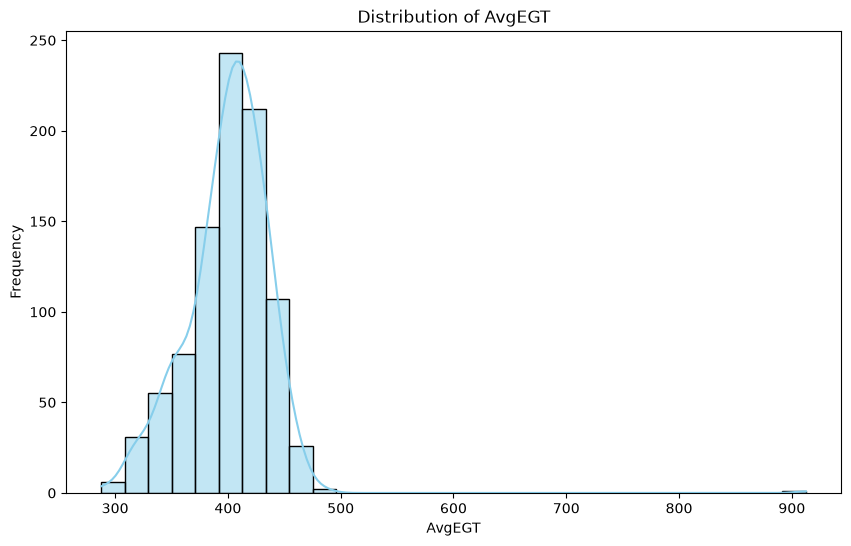

In [3]:
# Plot 1: Target Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True, color='skyblue')
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Frequency')
plt.show()

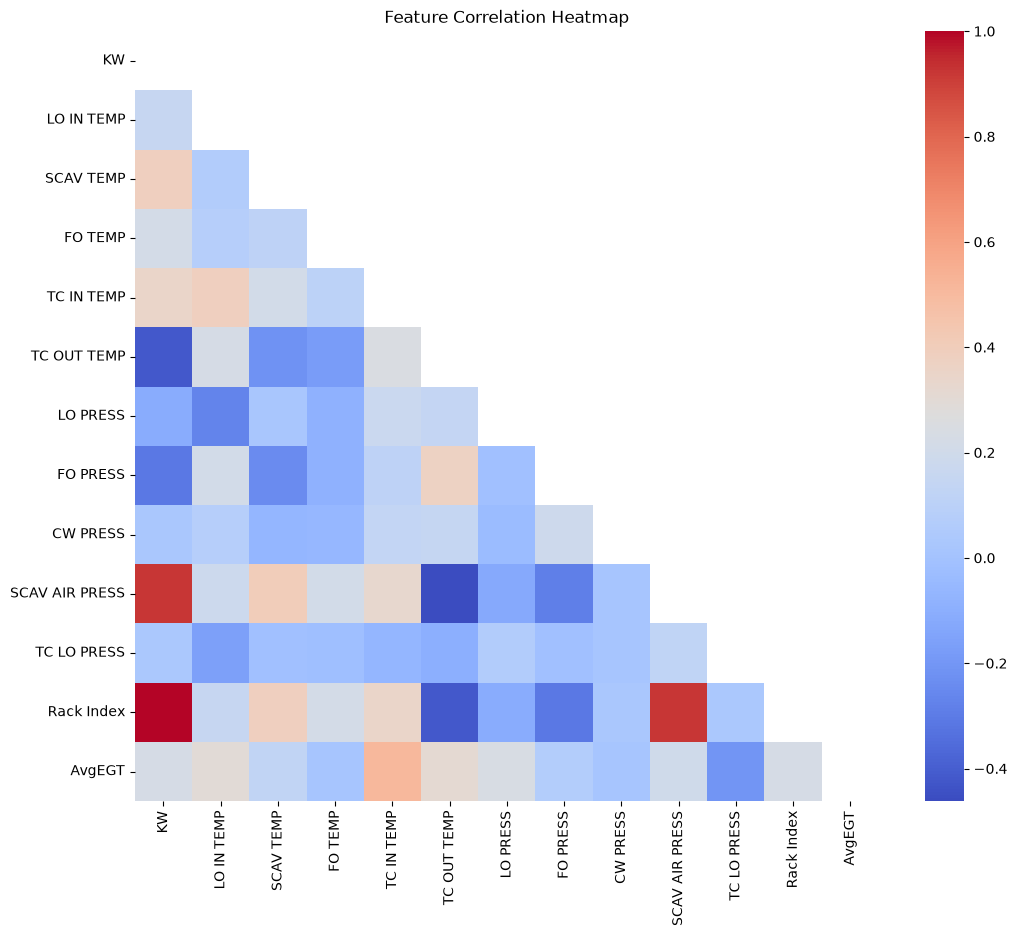

In [4]:
# Plot 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

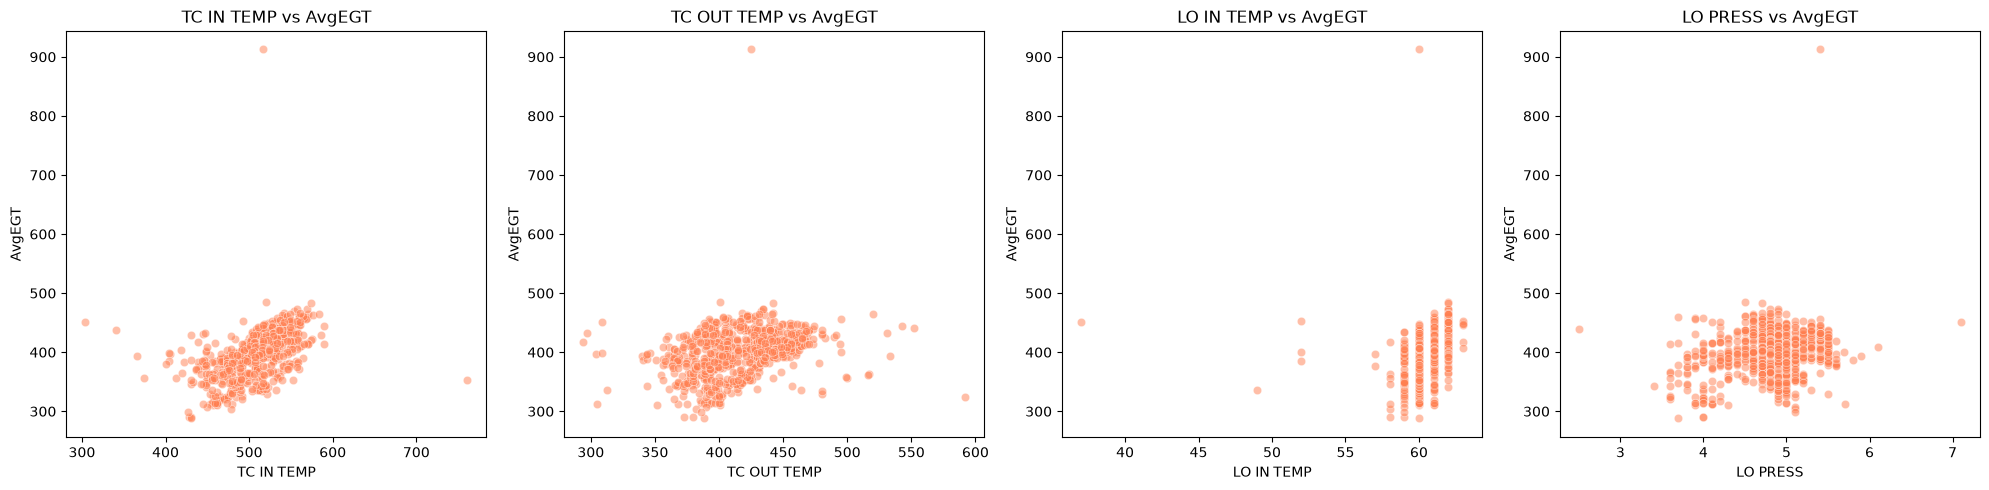

In [5]:
# Plot 3: Top Correlated Features vs Target
top_corr_features = corr_matrix[TARGET_COL].abs().sort_values(ascending=False).index[1:5]
plt.figure(figsize=(20, 5))
for i, feature in enumerate(top_corr_features, 1):
    plt.subplot(1, len(top_corr_features), i)
    sns.scatterplot(data=df_clean, x=feature, y=TARGET_COL, alpha=0.5, color='coral')
    plt.title(f'{feature} vs {TARGET_COL}')
plt.tight_layout()
plt.show()

## 3. Data Preparation & Model Training
We will split our data into training (90%) and testing (10%) sets, standardize the numerical features, and train a suite of models including XGBoost, which tends to perform extremely well on this dataset.

In [6]:
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

# Including all models from the original project to ensure the true winner (usually XGBoost) is captured
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=500, max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
}

results = []
best_r2 = -float('inf')

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse})
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model_instance = model
        best_y_pred = y_pred

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,R2,RMSE
4,XGBoost,0.913600,10.830658
3,ExtraTrees,0.891184,12.154711
2,Random Forest,0.877870,12.876889
0,Linear Regression,0.723701,19.368191
1,Decision Tree,0.656617,21.591791


## 4. Model Evaluation & Diagnostics (Core Plots)
Let's visually compare the models and dive deep into the winning model's performance.

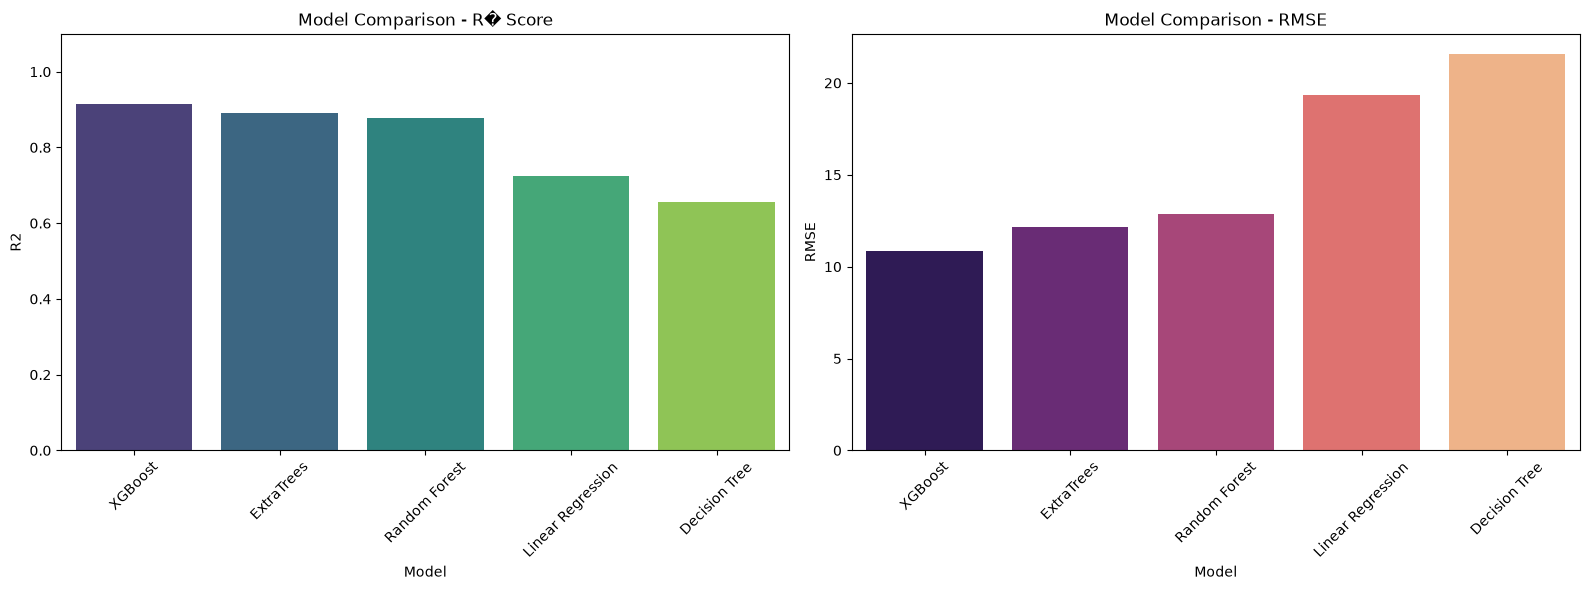

In [7]:
# Plot 4 & 5: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=results_df, x='Model', y='R2', palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison - R� Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x='Model', y='RMSE', palette='magma', ax=axes[1])
axes[1].set_title('Model Comparison - RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

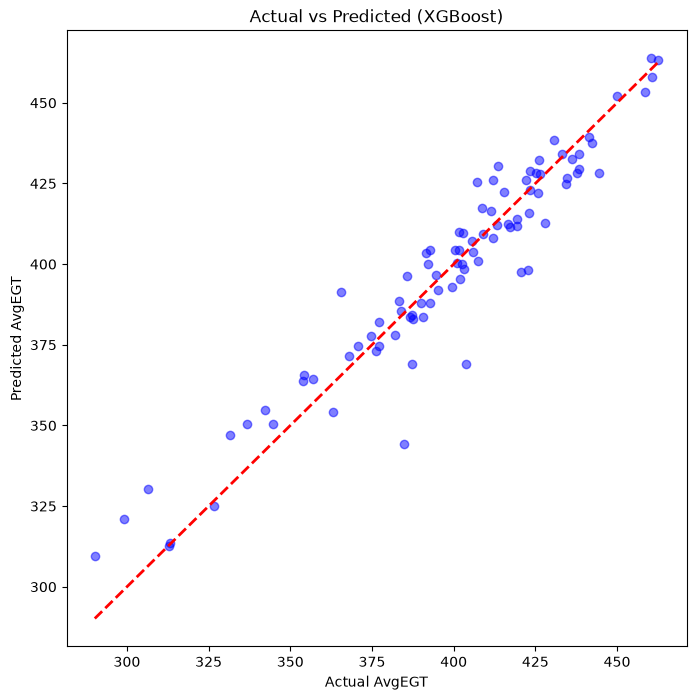

In [8]:
# Plot 6: Actual vs Predicted (Best Model)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.xlabel('Actual AvgEGT')
plt.ylabel('Predicted AvgEGT')
plt.show()

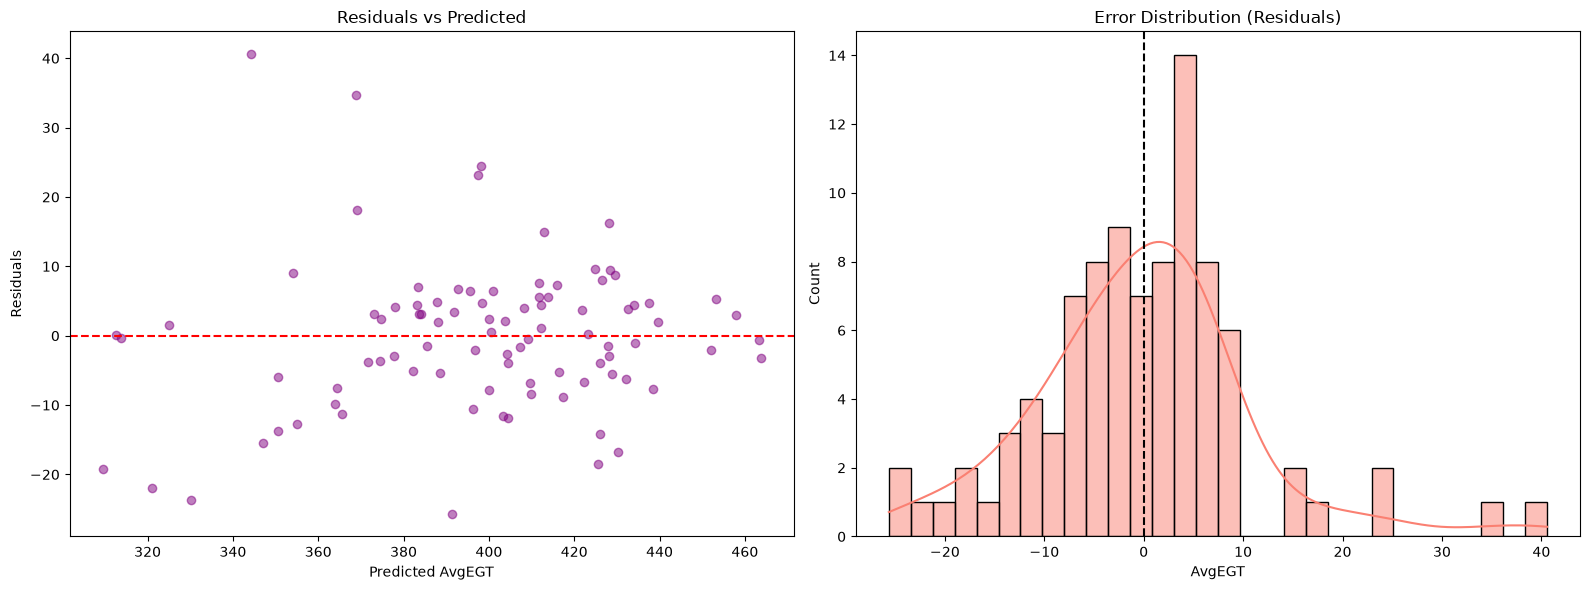

In [9]:
# Plot 7 & 8: Residual Diagnostics
residuals = y_test - best_y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(best_y_pred, residuals, alpha=0.5, color='purple')
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted AvgEGT')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Error Distribution (Residuals)')

plt.tight_layout()
plt.show()

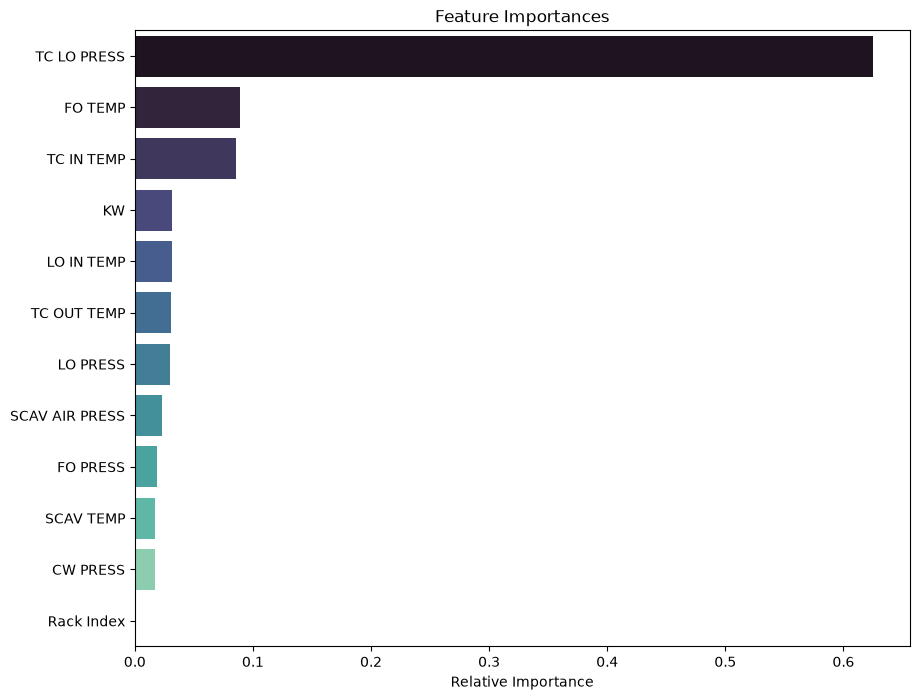

In [10]:
# Plot 9: Feature Importance
if hasattr(best_model_instance, 'feature_importances_'):
    importances = best_model_instance.feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_features = [X.columns[i] for i in indices]

    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances[indices], y=sorted_features, palette='mako')
    plt.title('Feature Importances')
    plt.xlabel('Relative Importance')
    plt.show()

## 5. Exhaustive Plot Generation (Inline)
This section programmatically generates all ~220 plots across the entire dataset and renders them directly below the cell.
**Warning:** Depending on your machine, displaying hundreds of images inline may cause the notebook to consume significant memory.

Generating exhaustive Full Dataset EDA loops (Inline)...


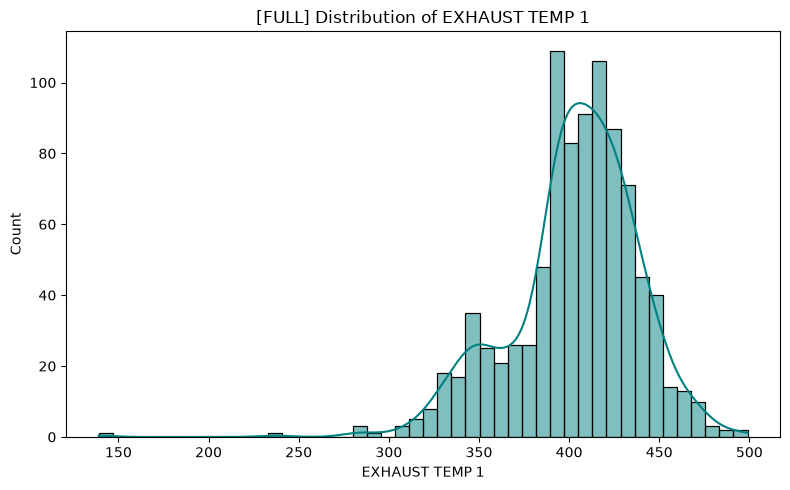

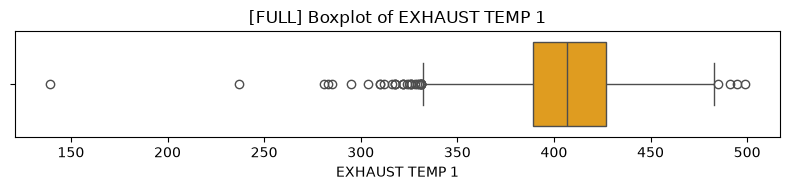

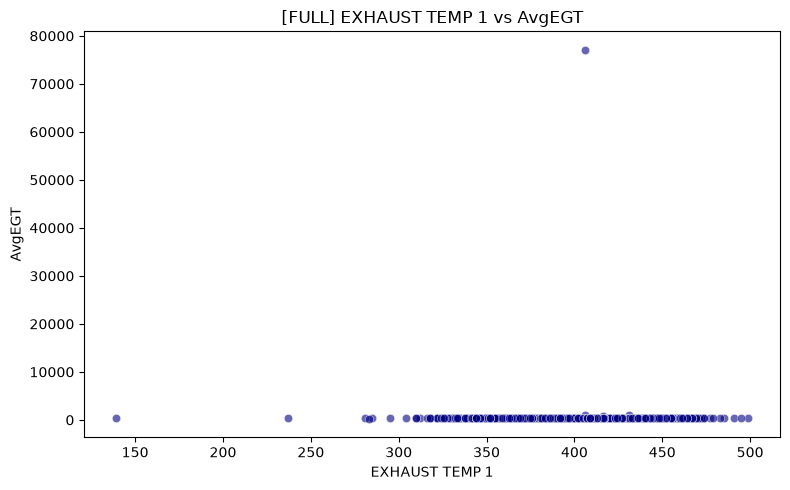

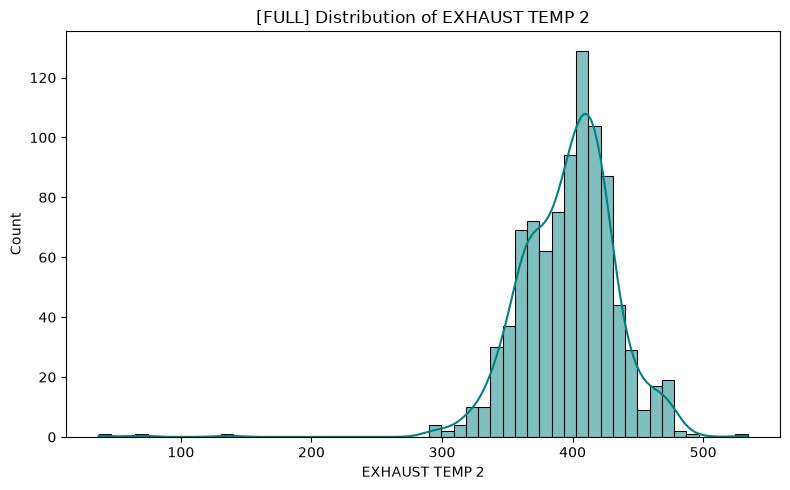

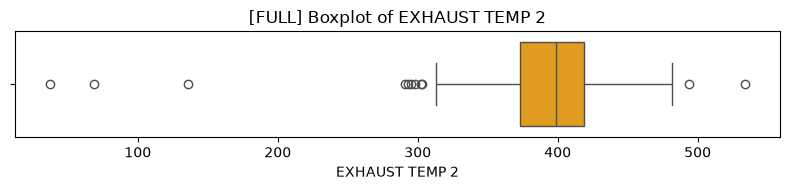

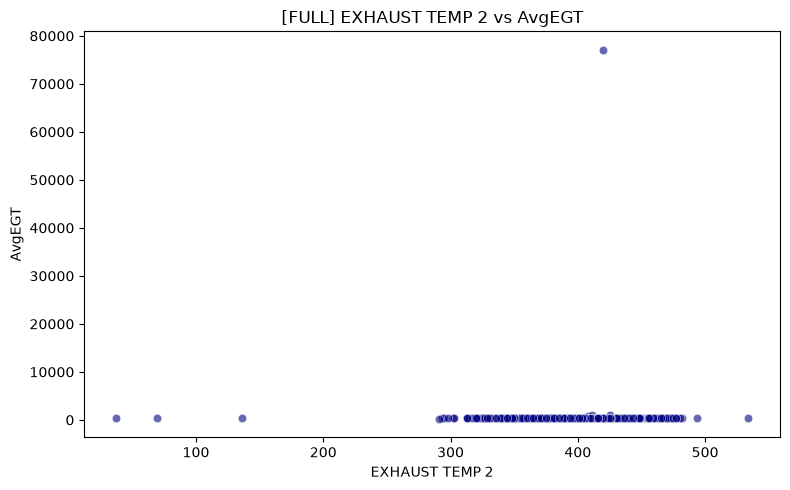

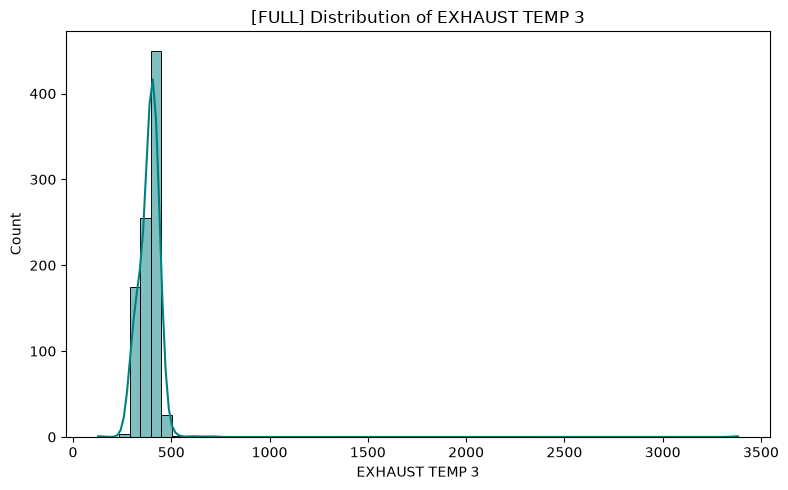

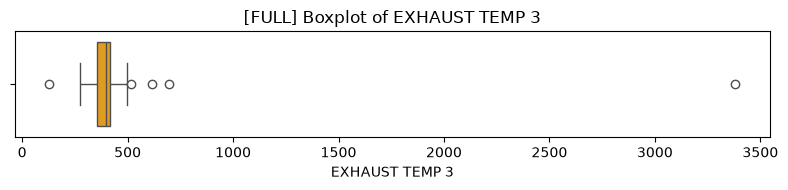

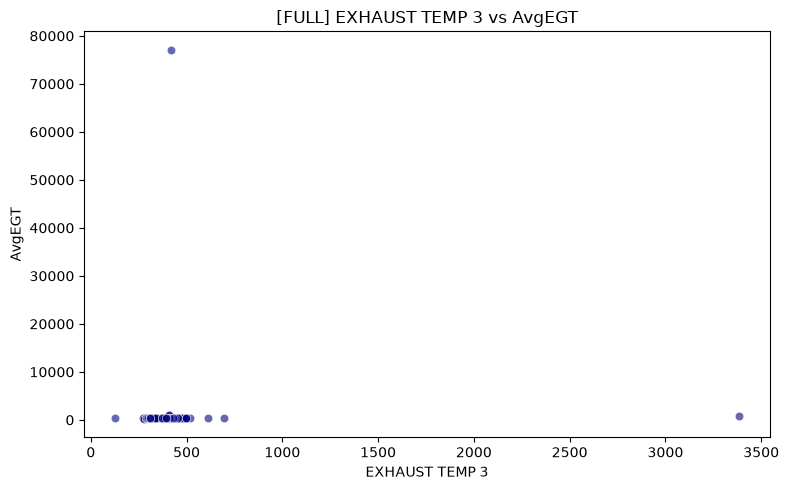

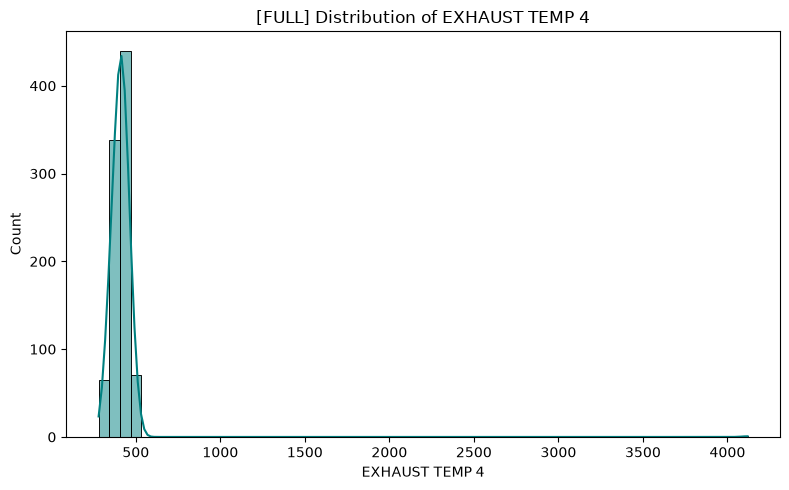

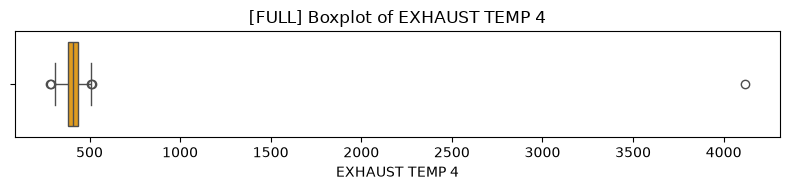

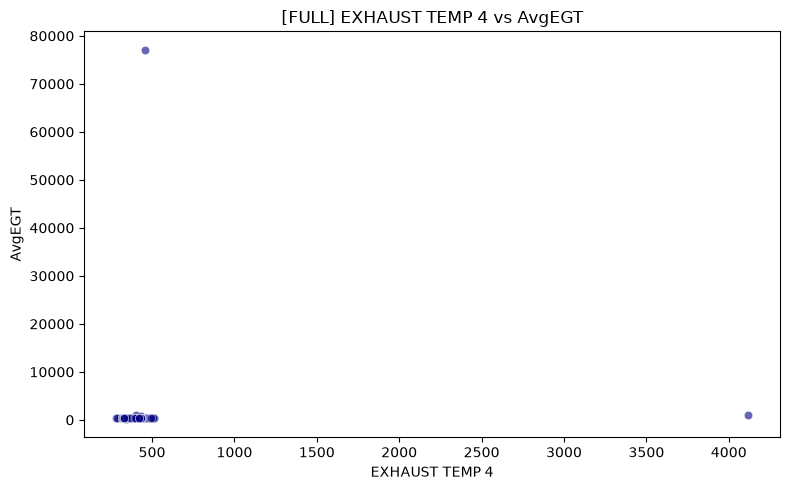

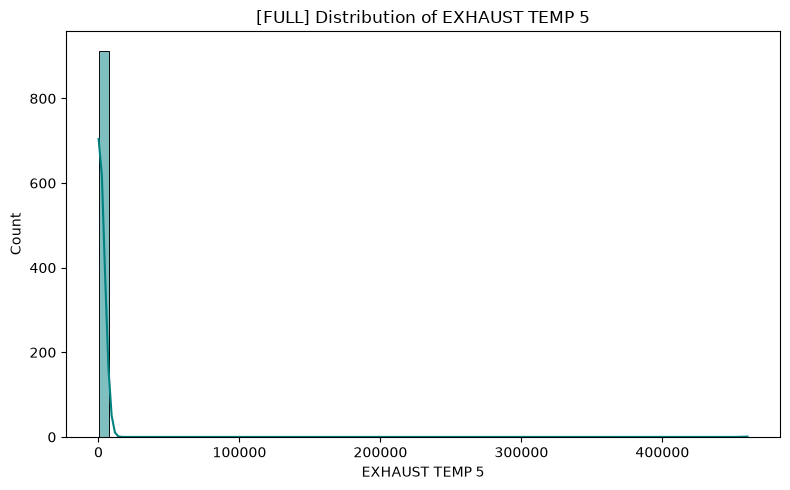

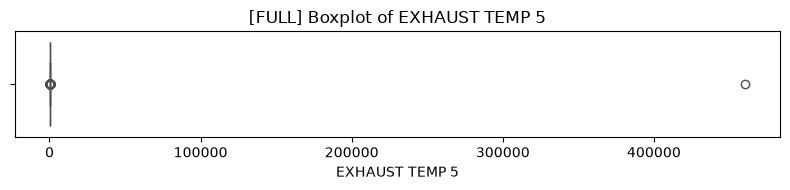

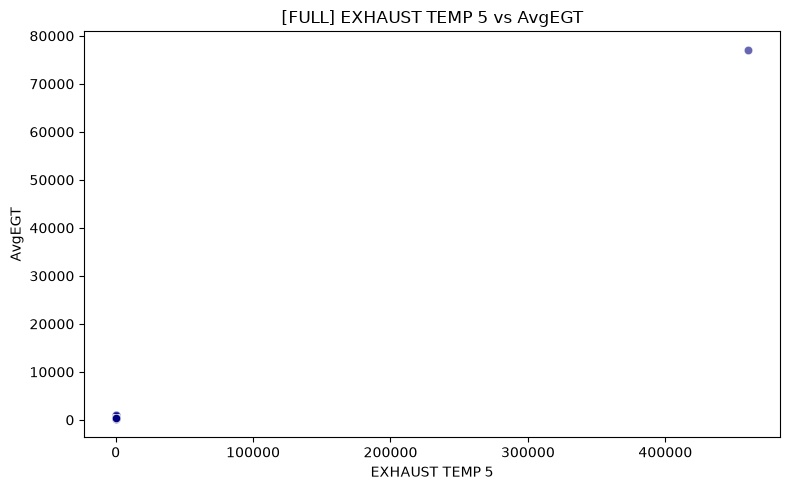

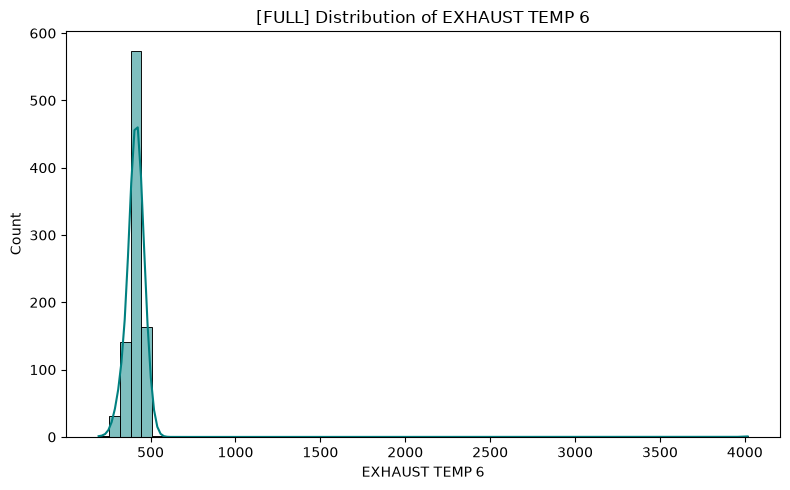

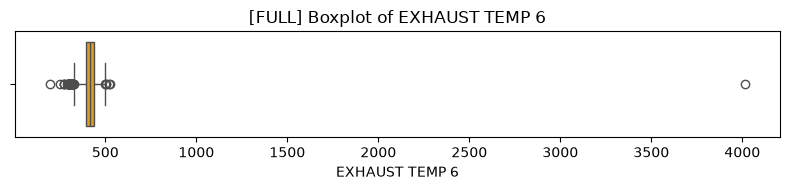

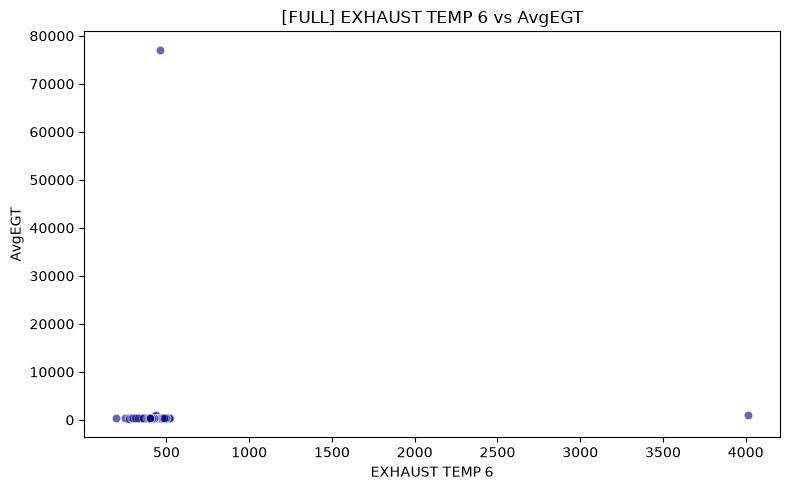

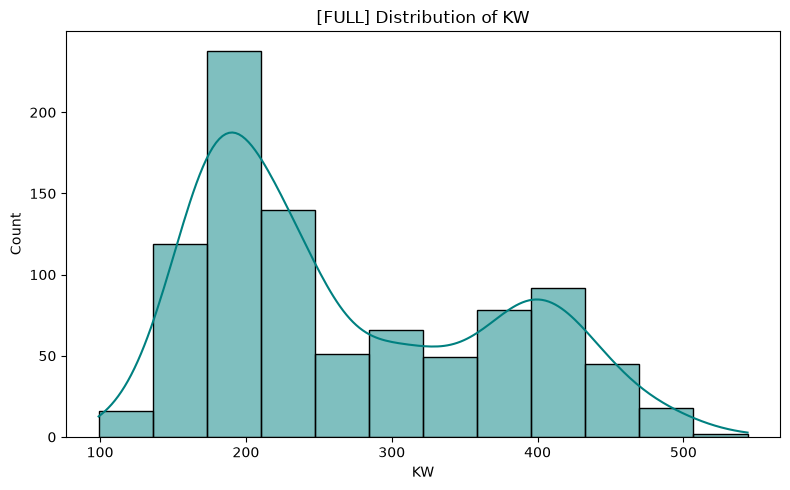

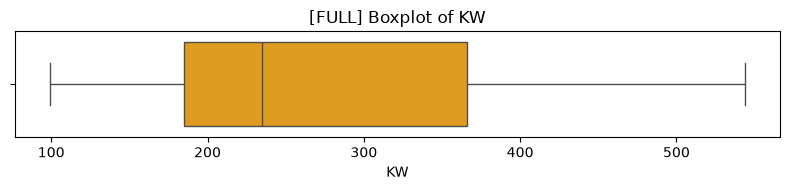

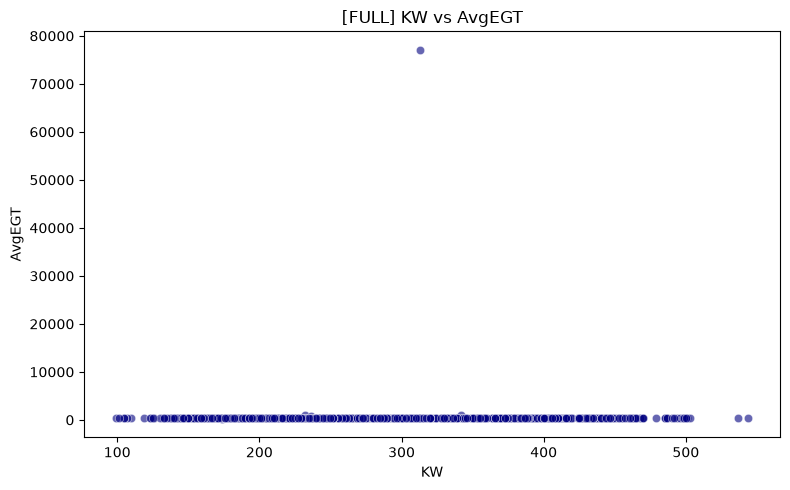

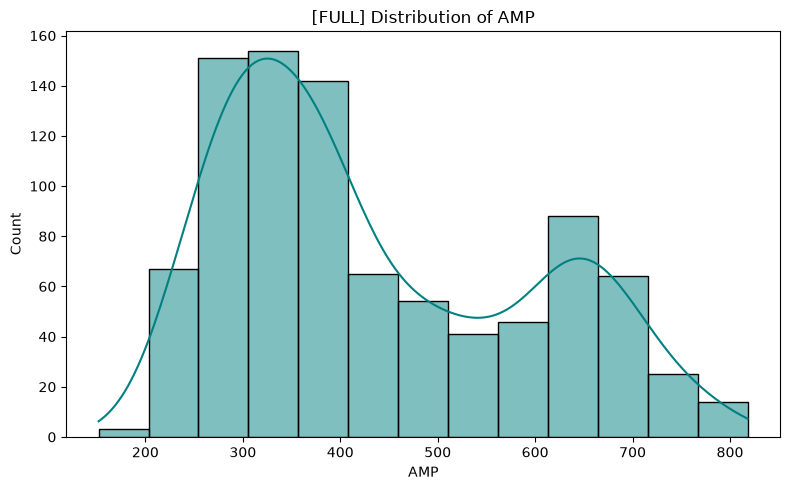

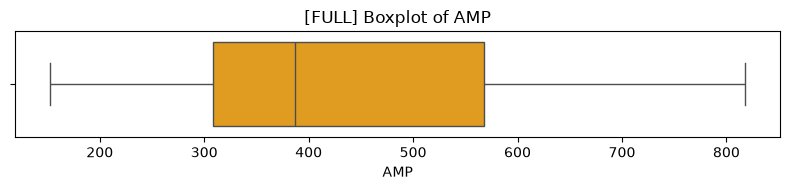

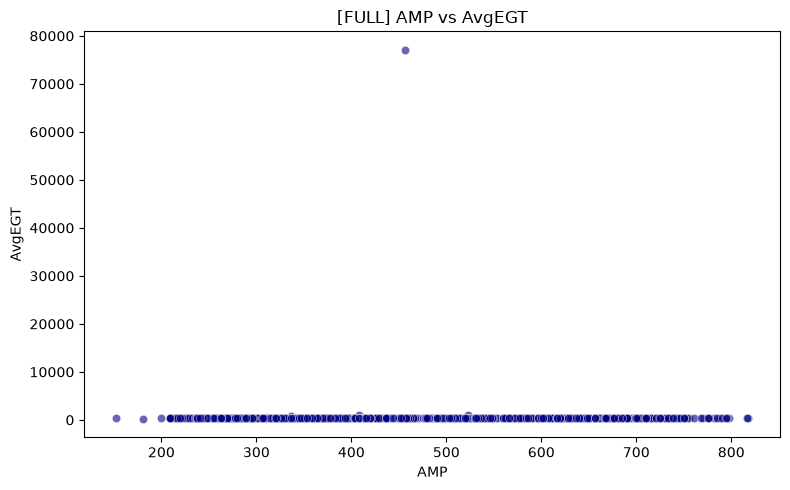

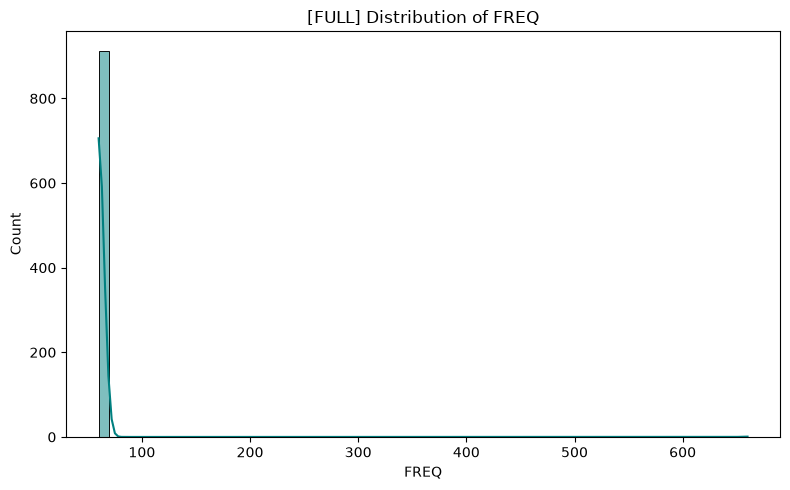

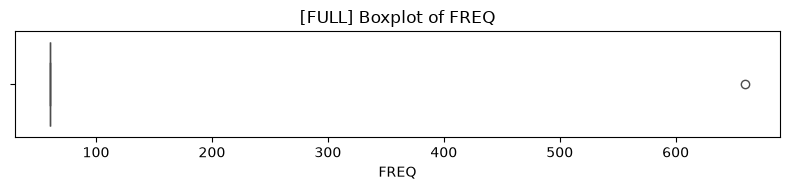

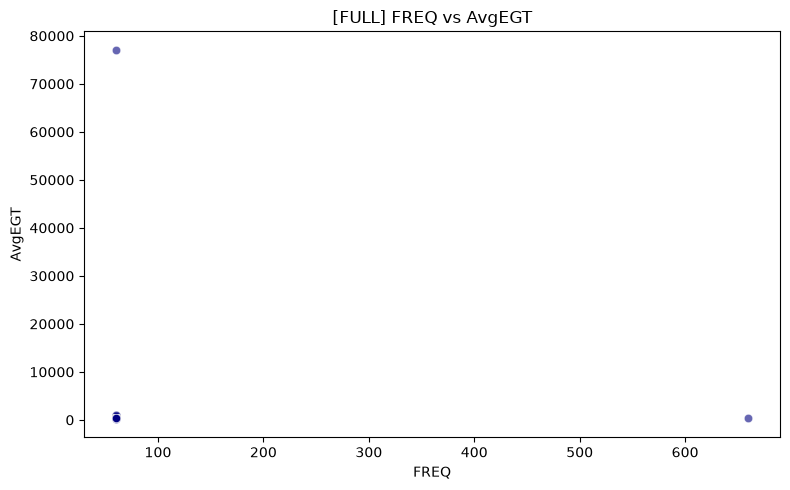

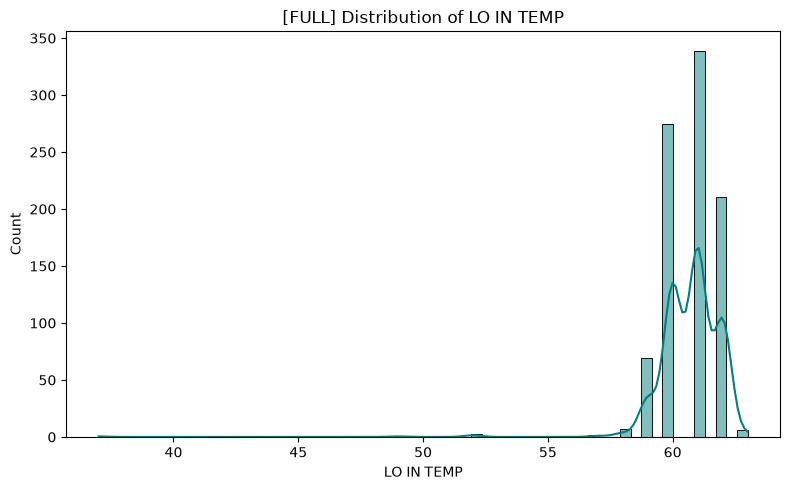

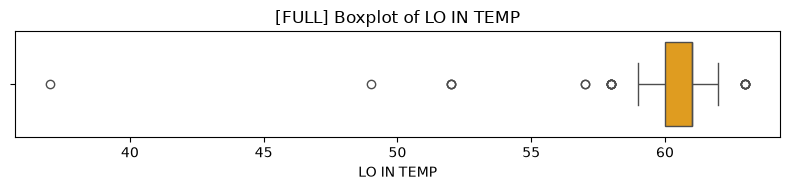

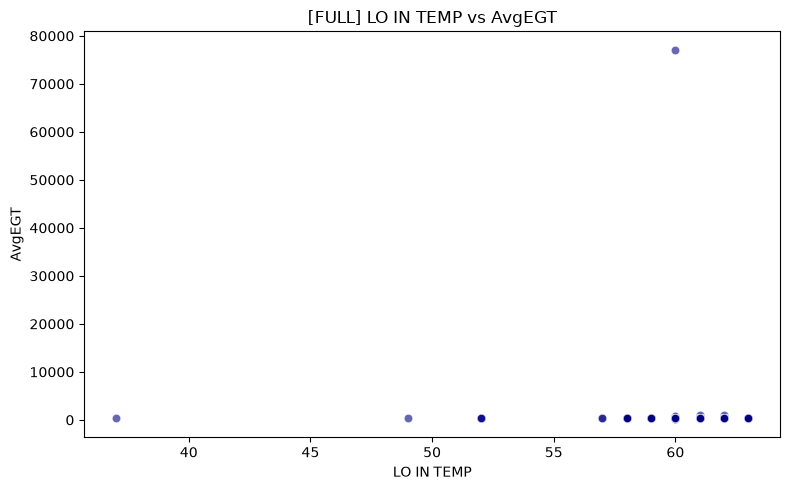

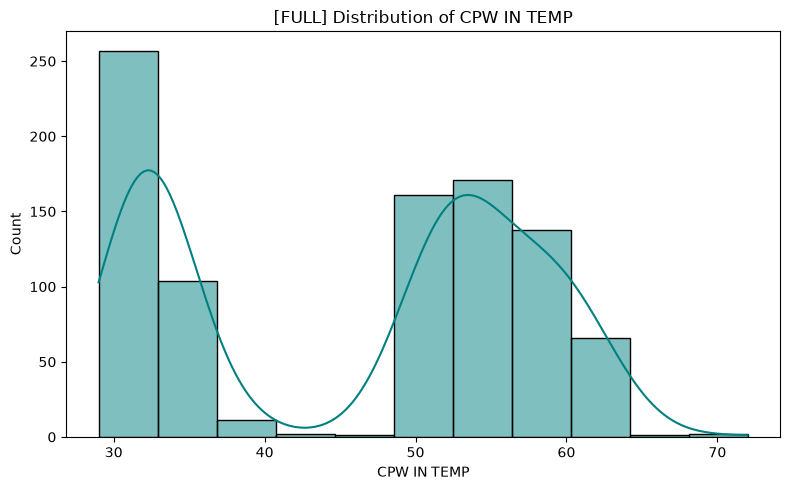

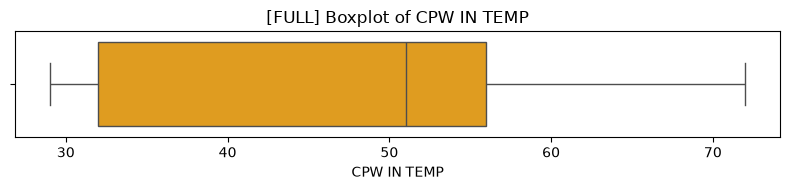

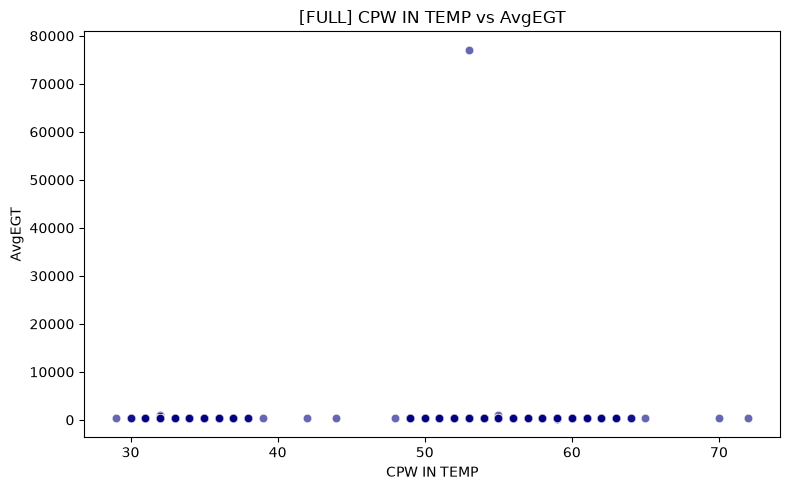

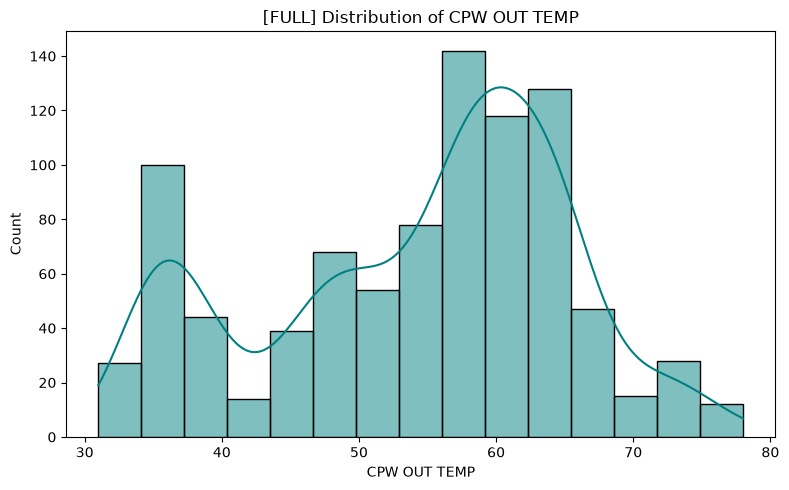

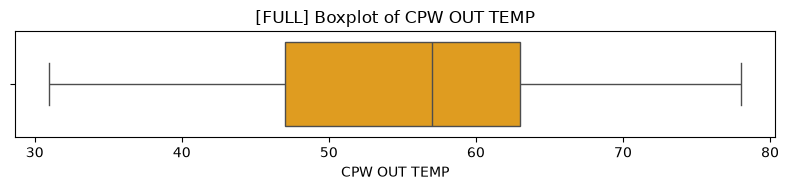

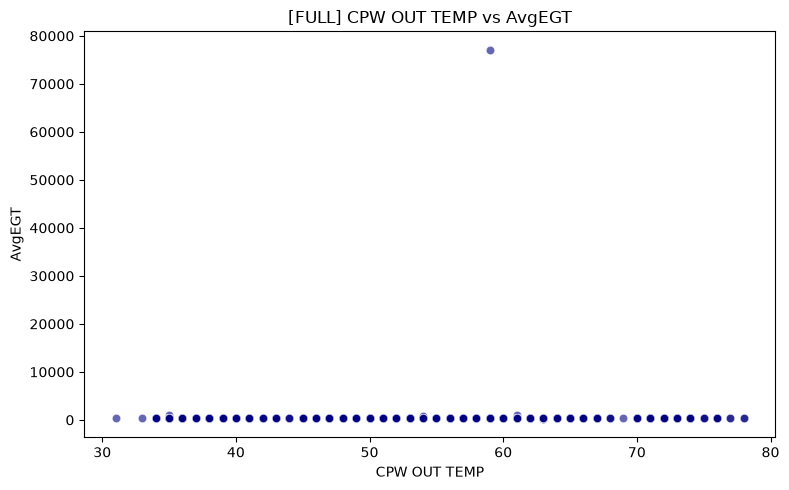

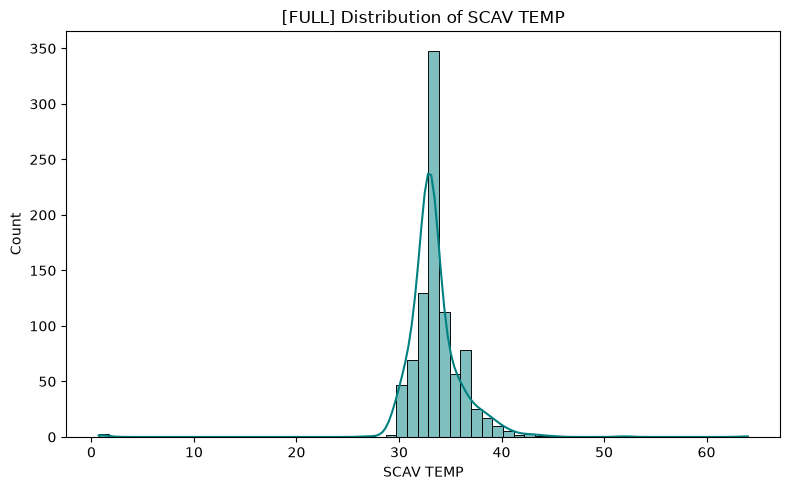

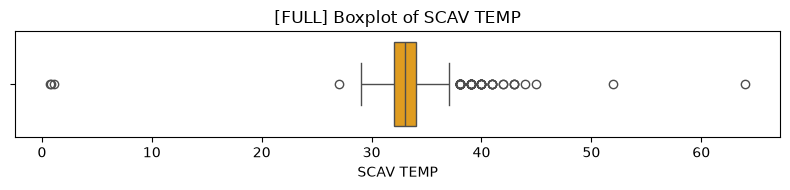

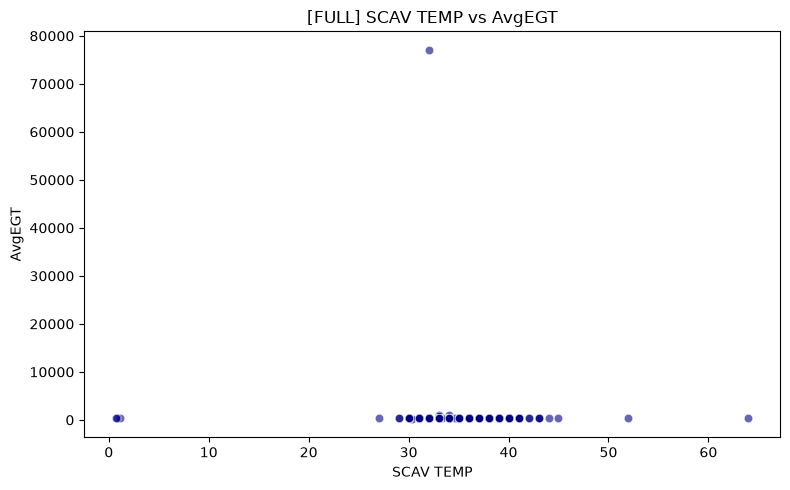

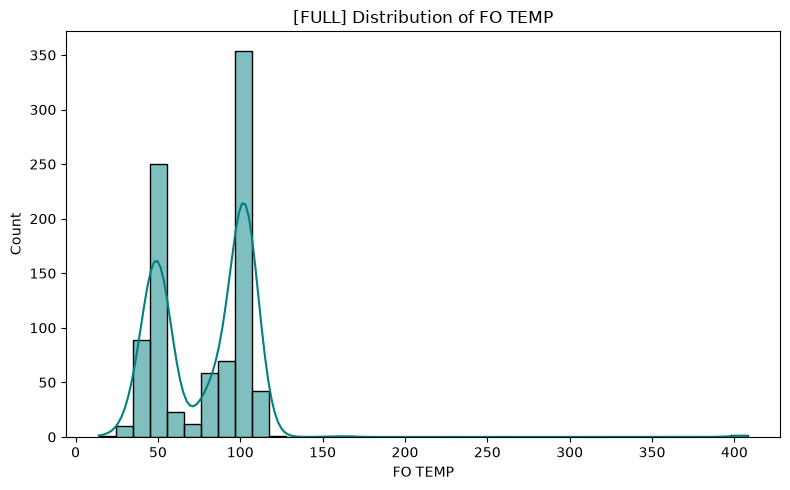

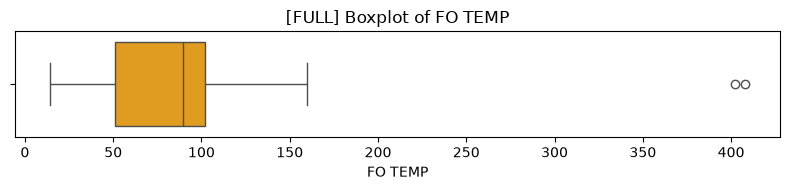

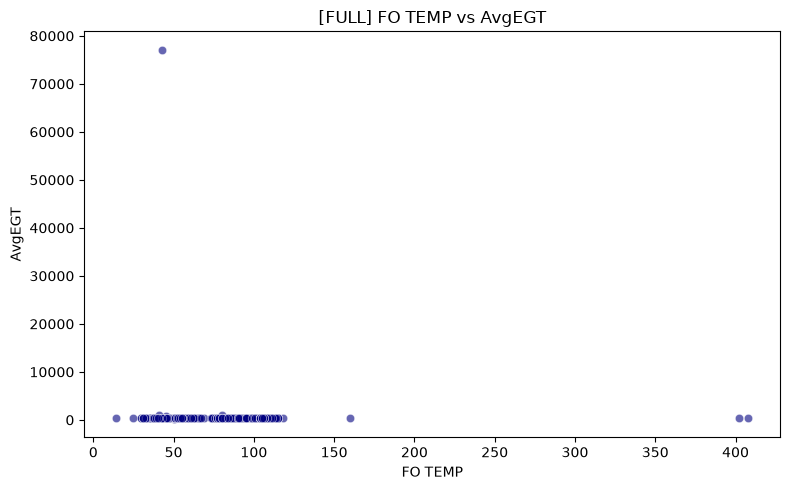

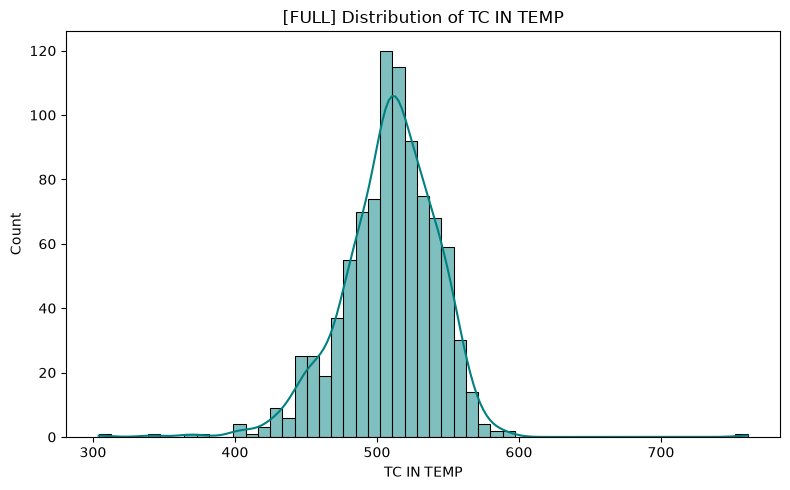

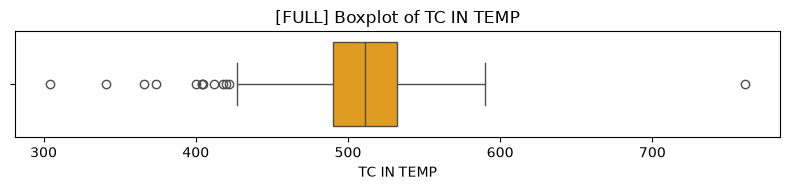

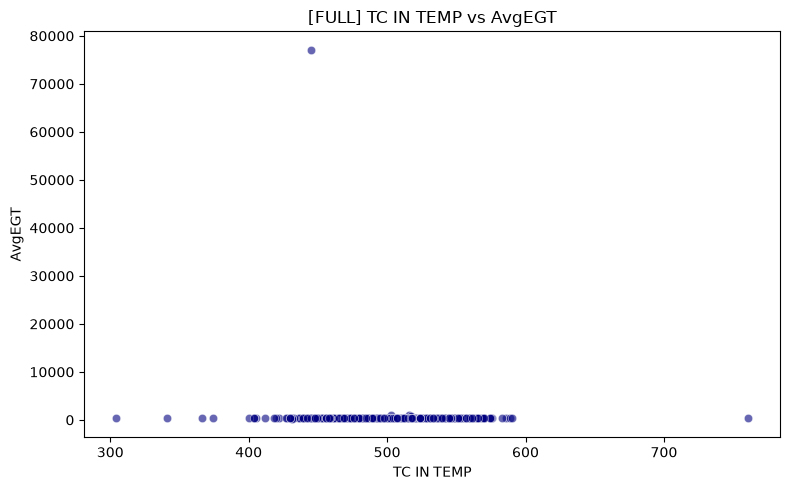

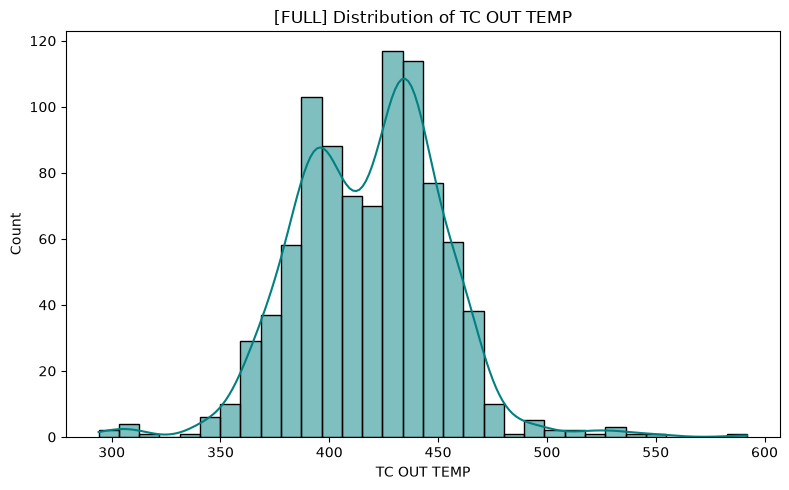

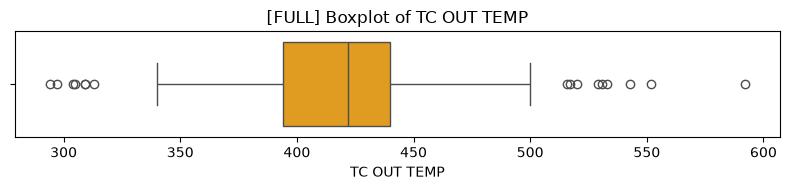

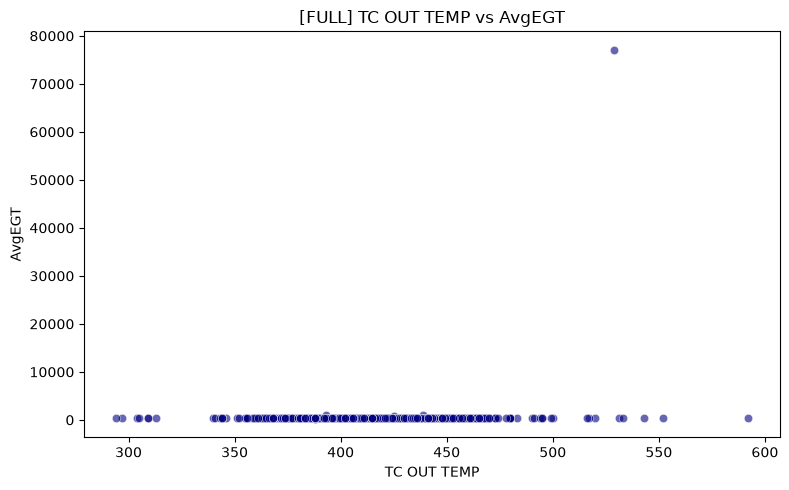

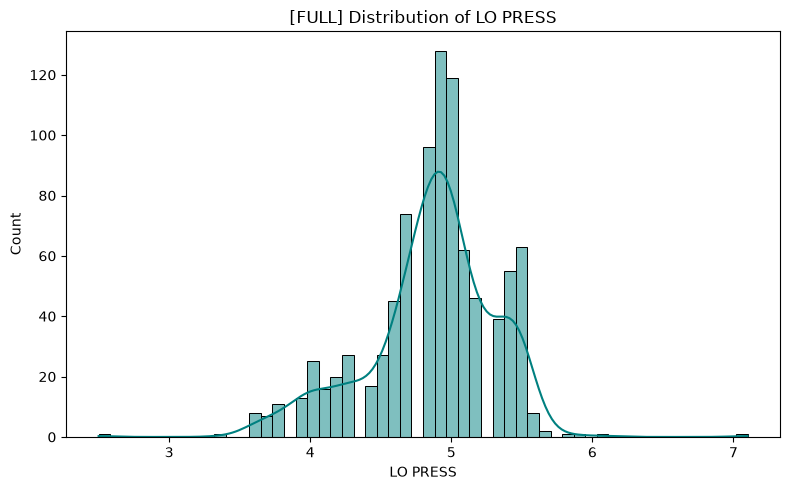

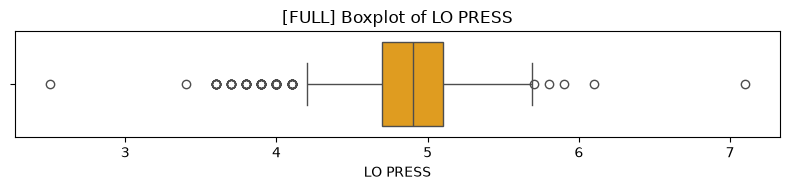

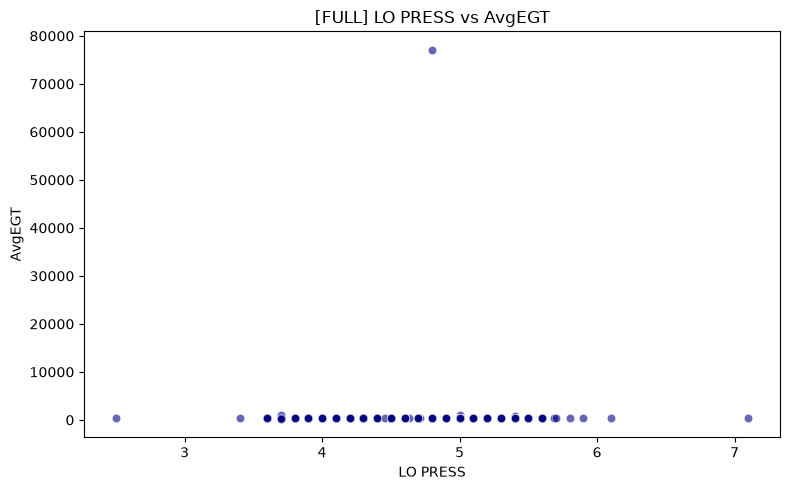

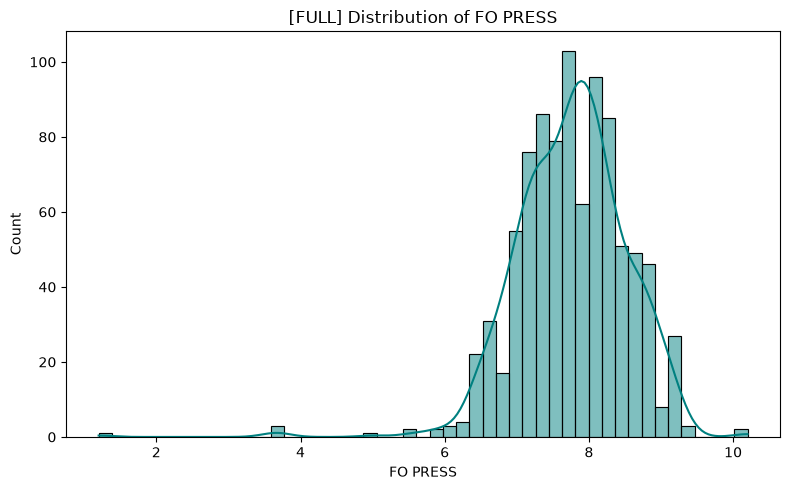

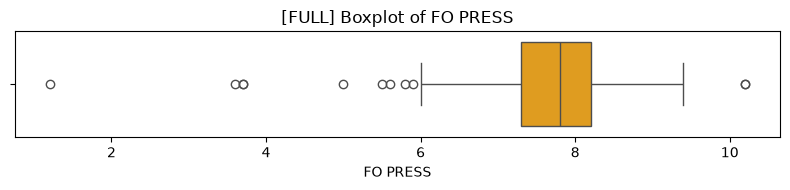

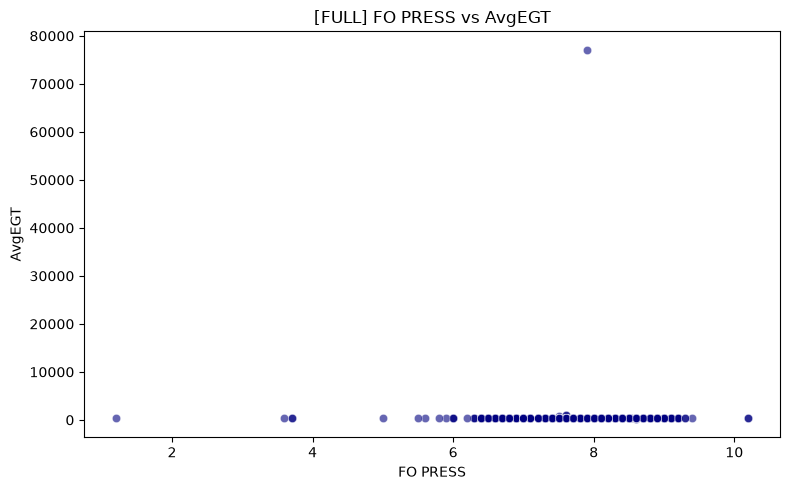

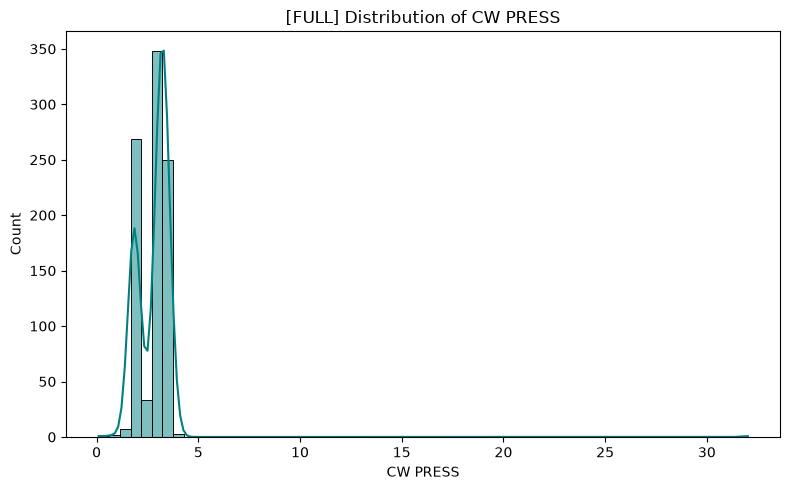

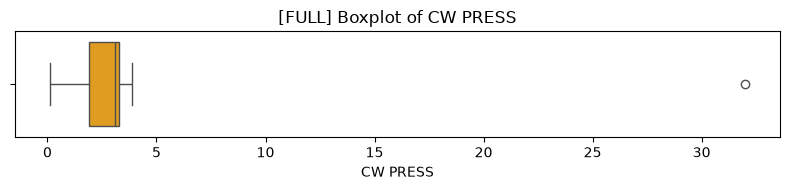

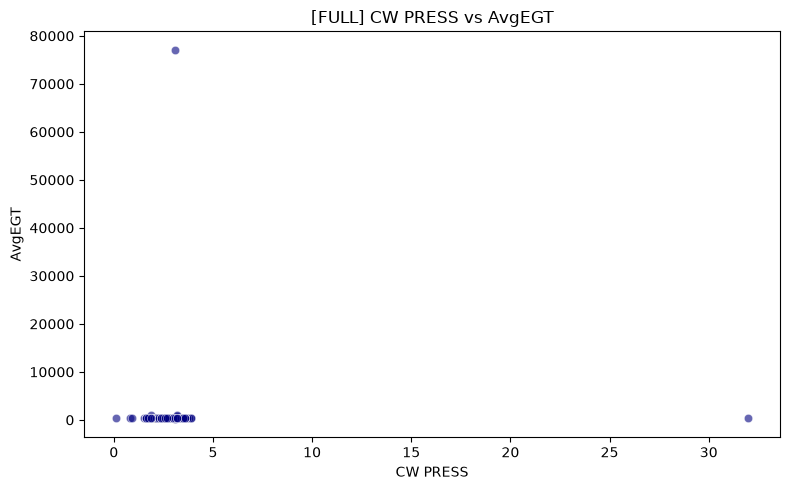

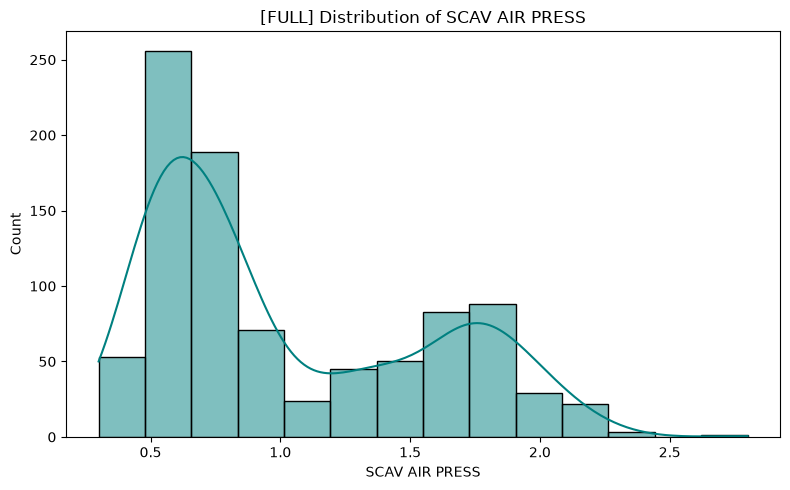

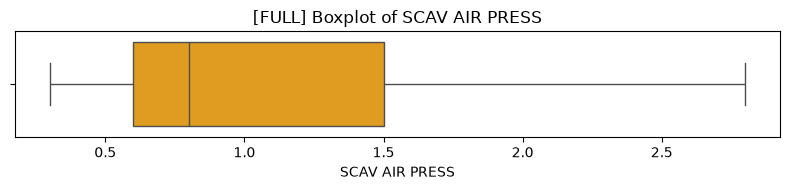

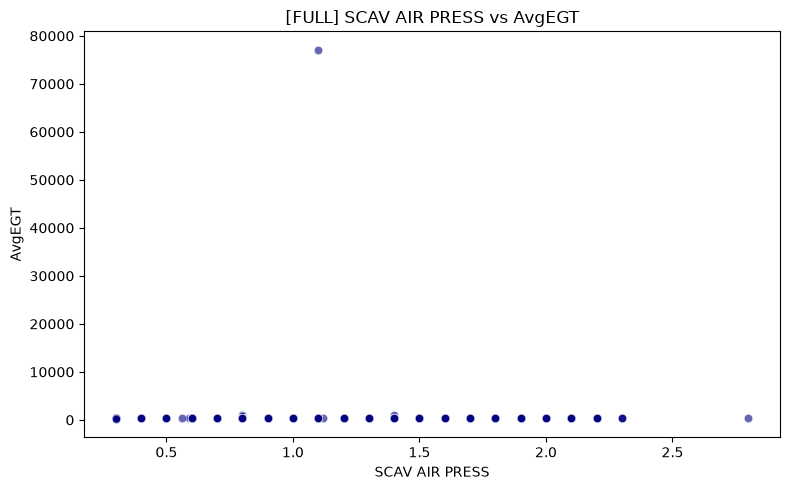

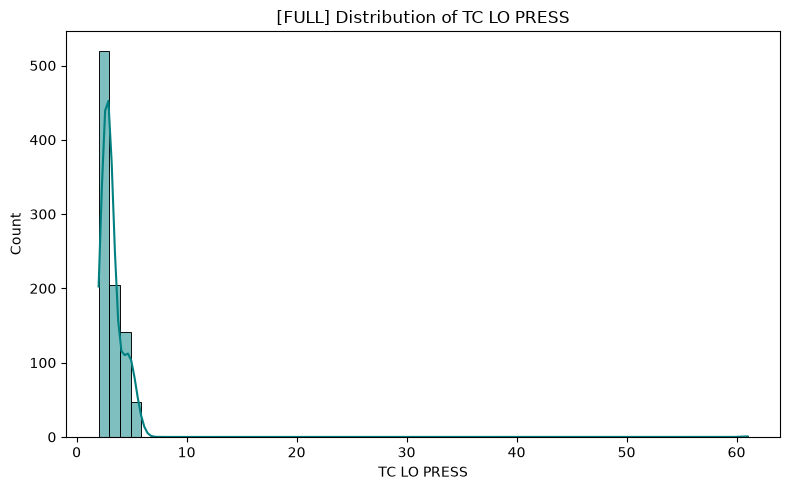

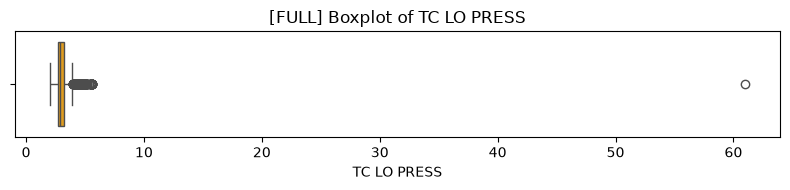

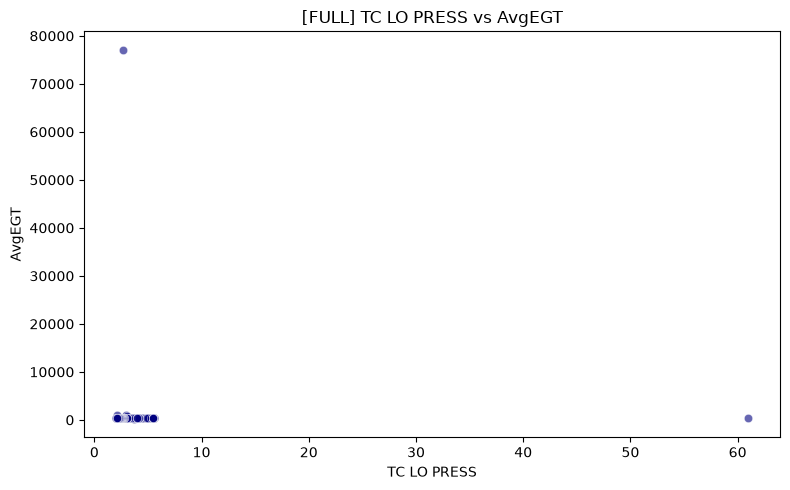

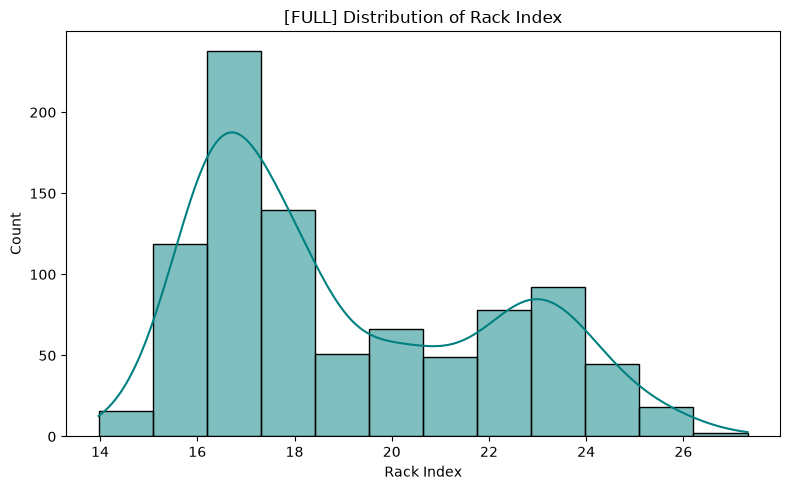

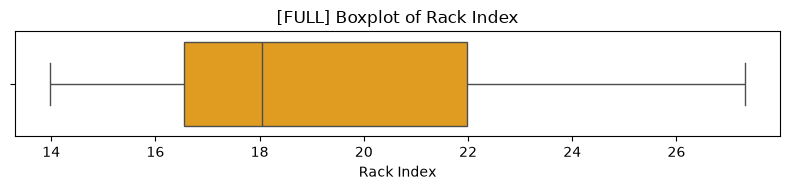

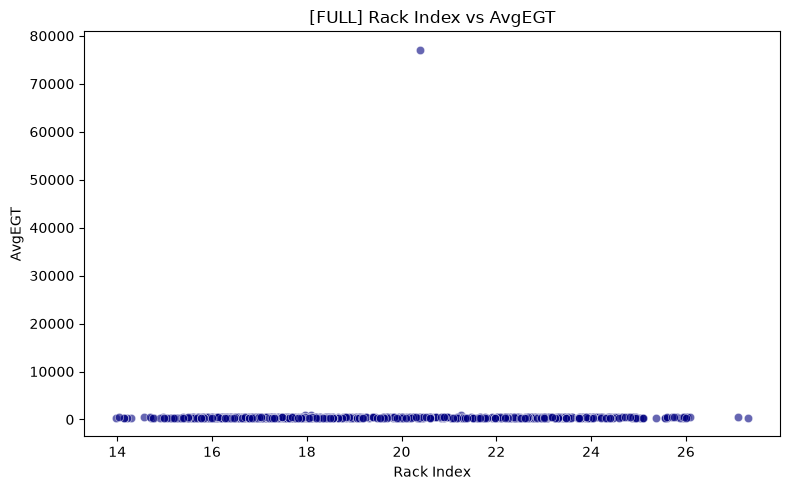

Generating exhaustive Sanitized Dataset EDA loops (Inline)...


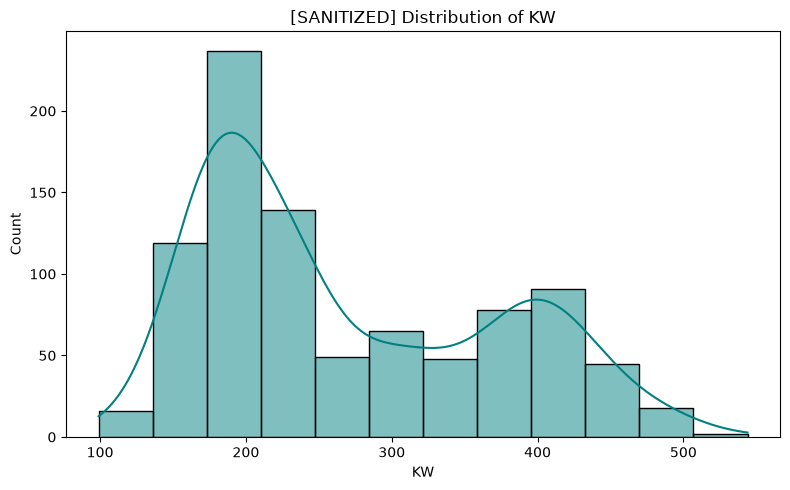

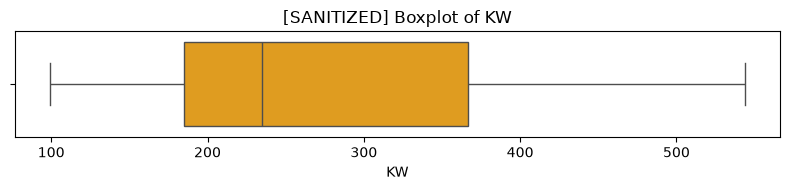

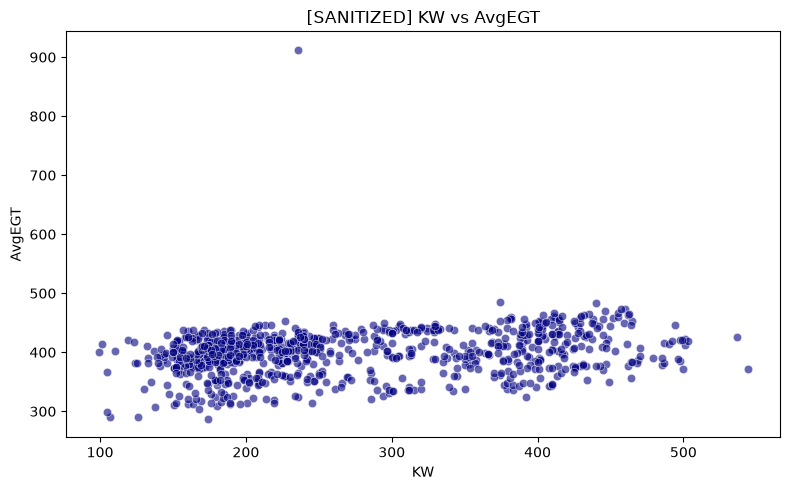

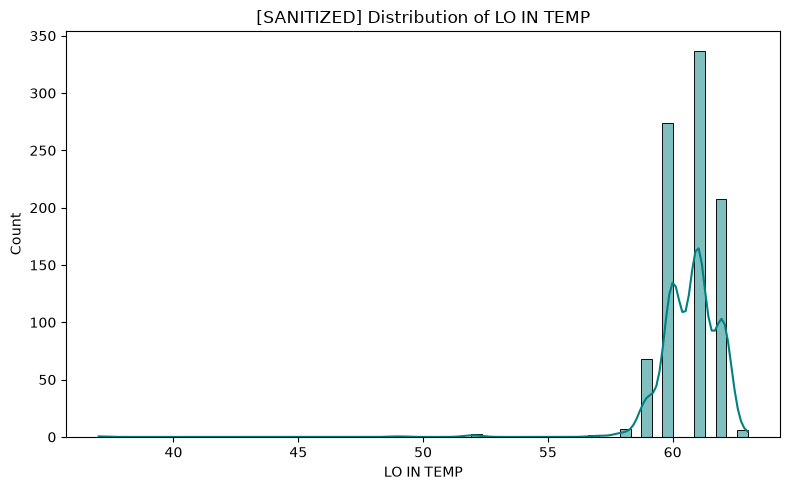

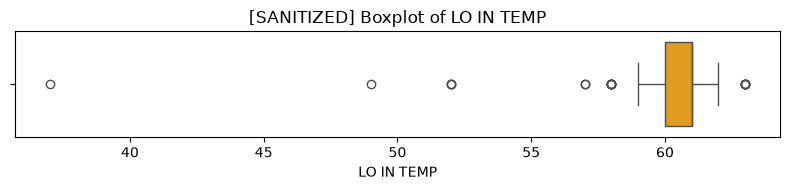

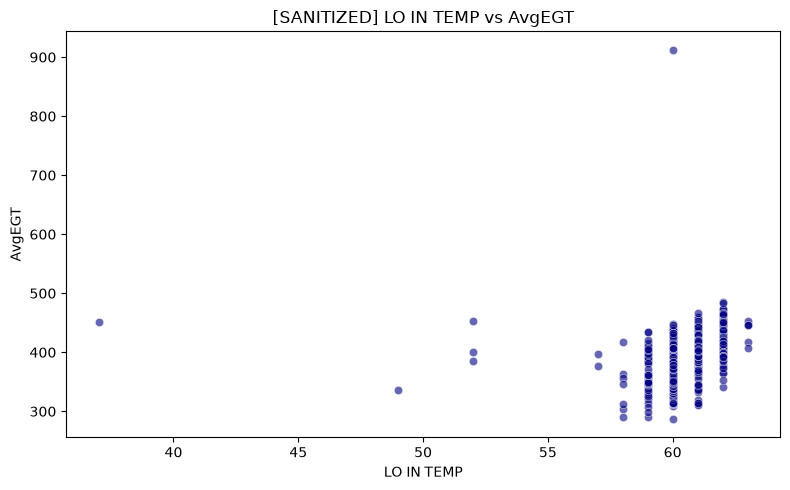

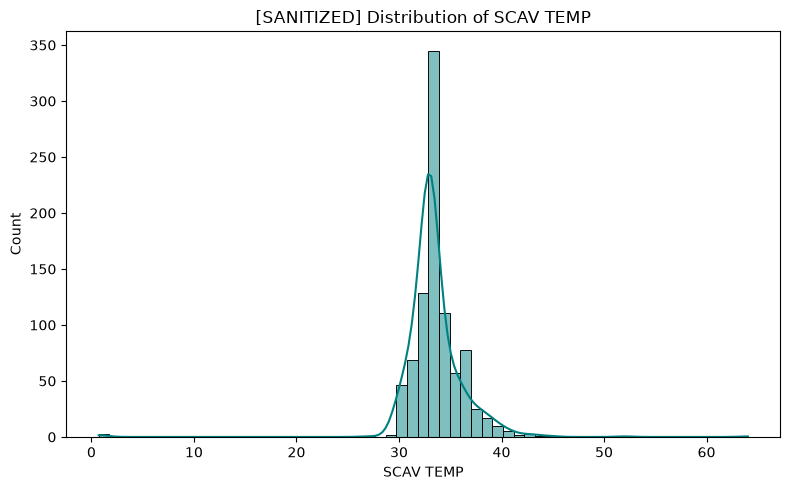

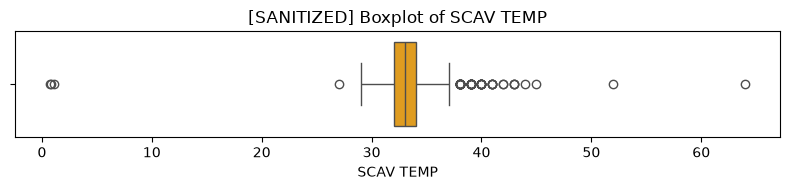

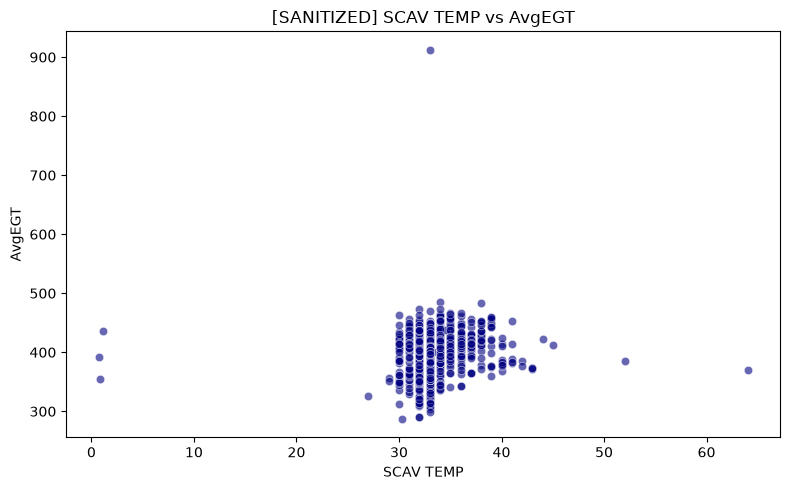

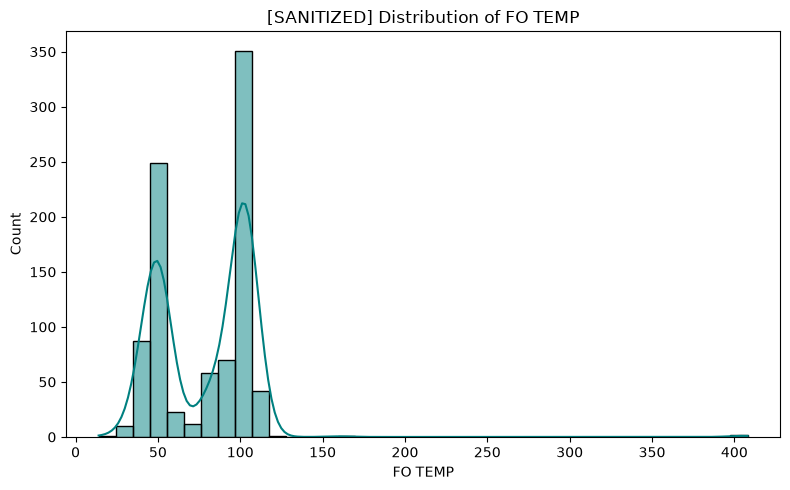

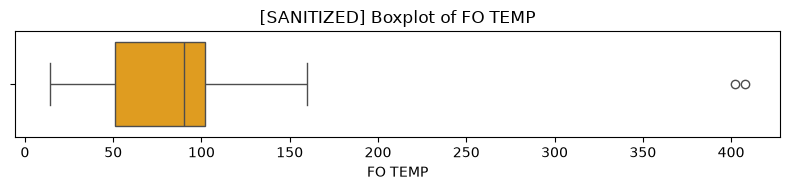

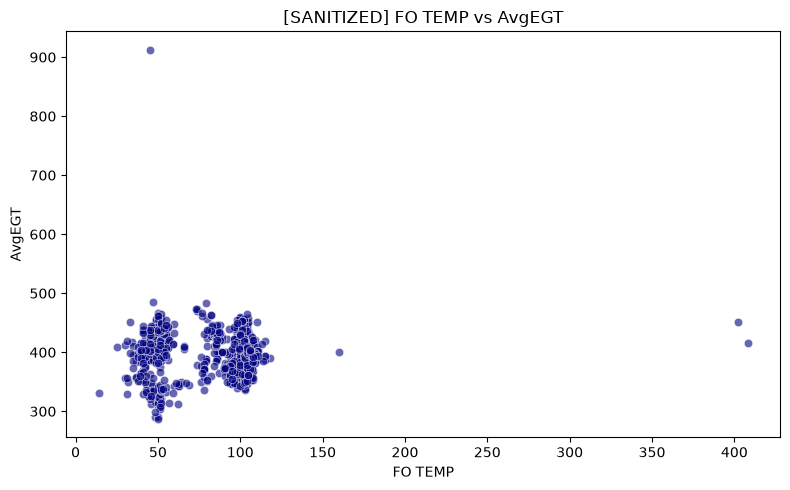

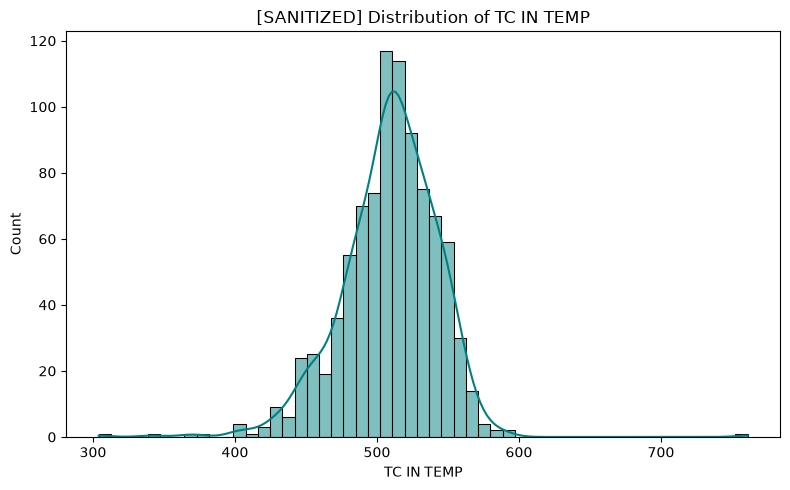

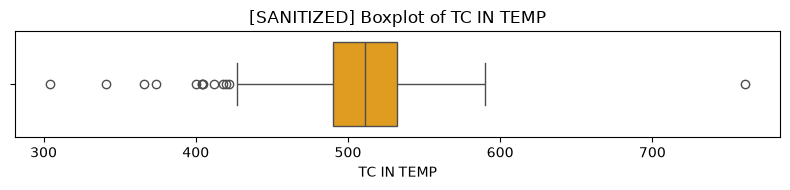

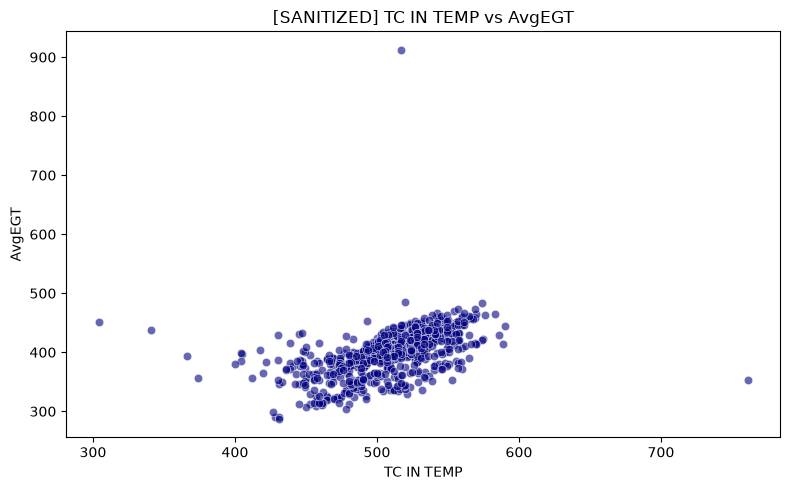

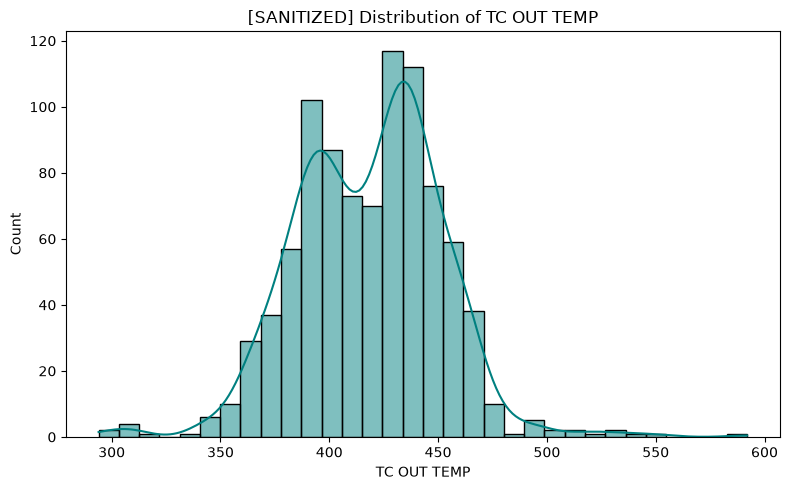

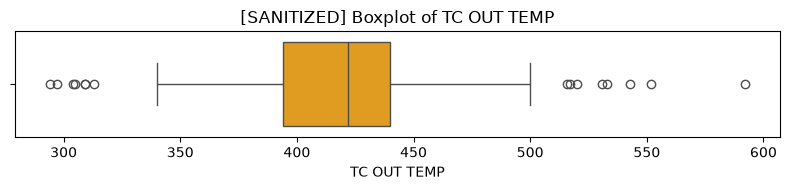

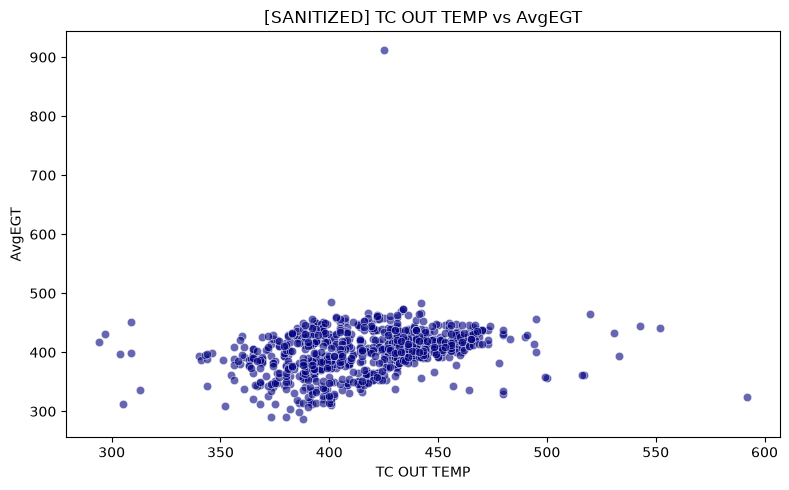

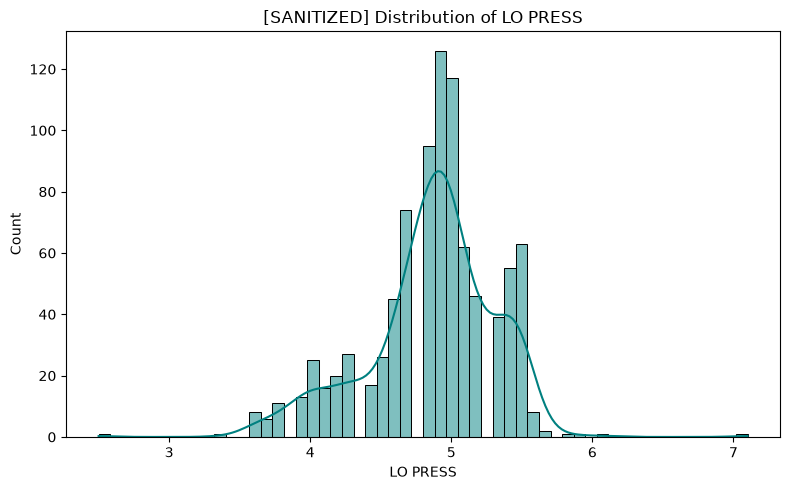

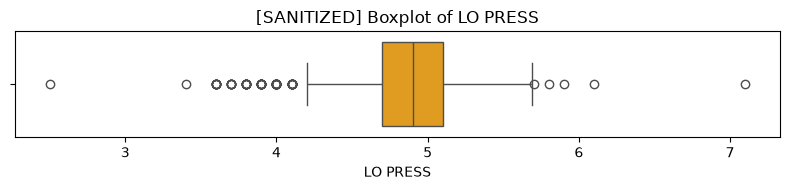

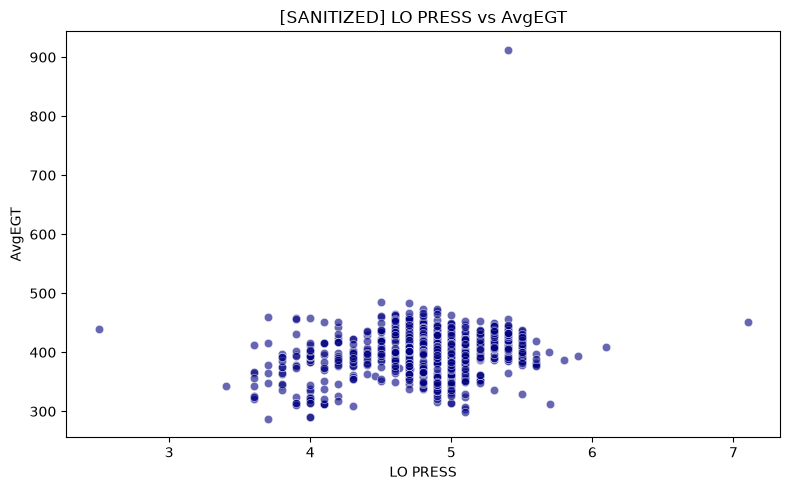

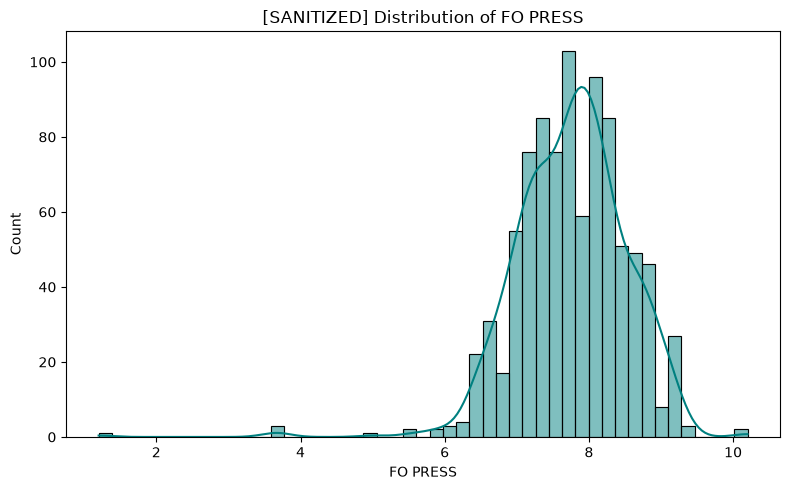

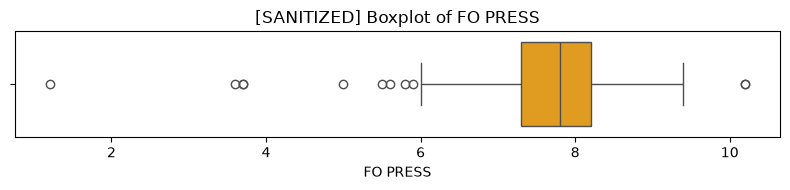

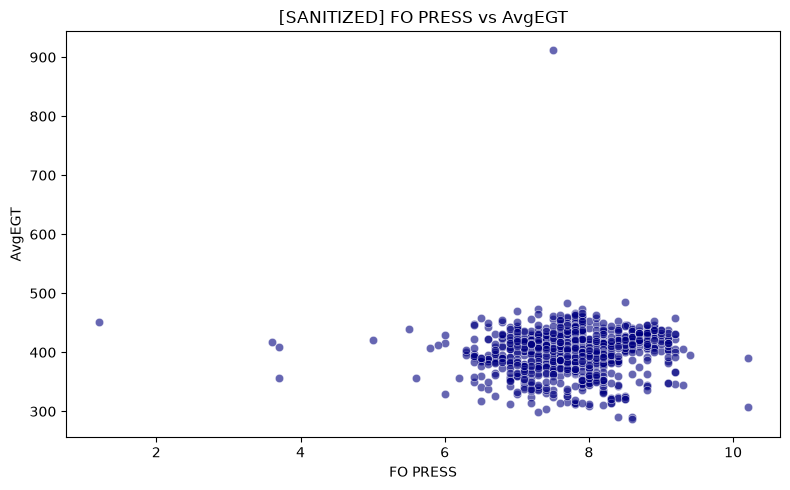

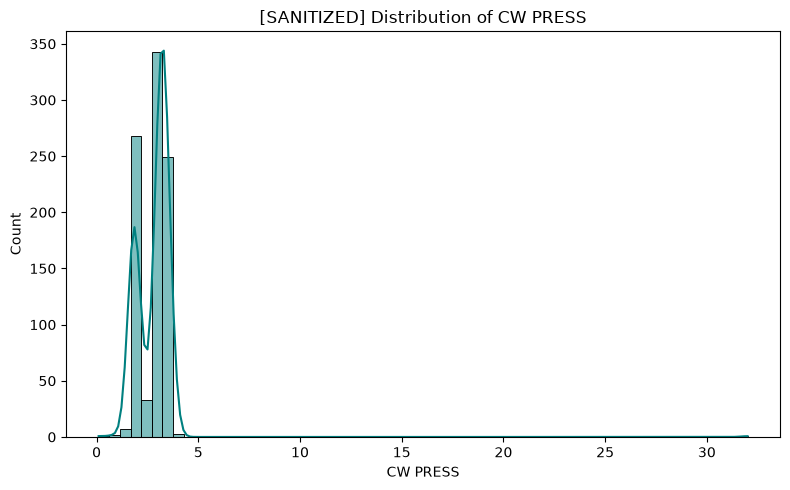

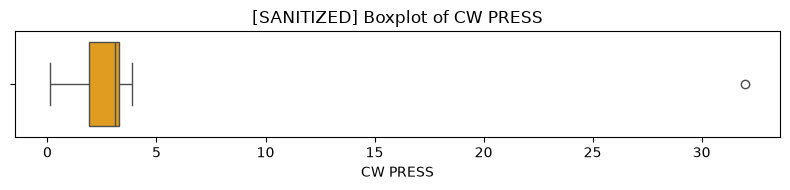

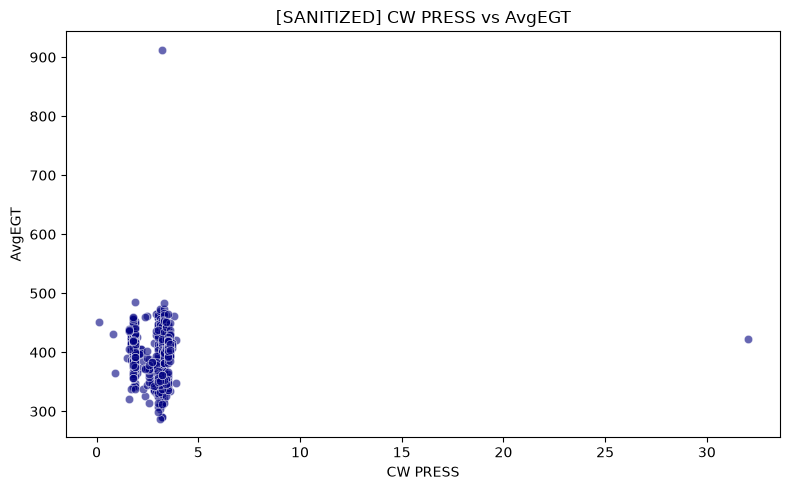

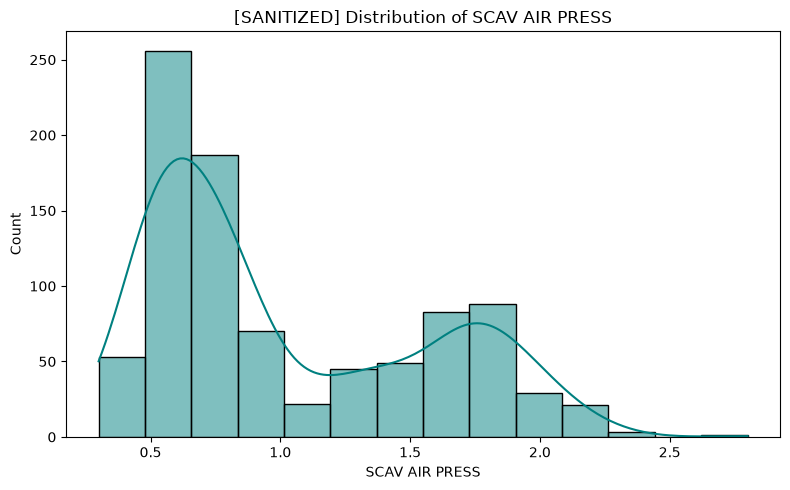

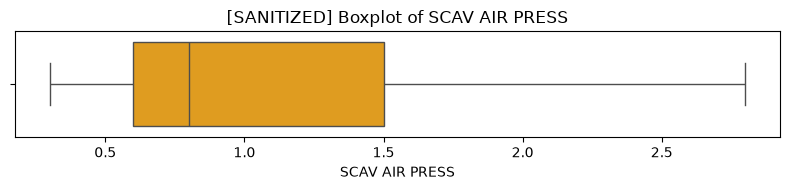

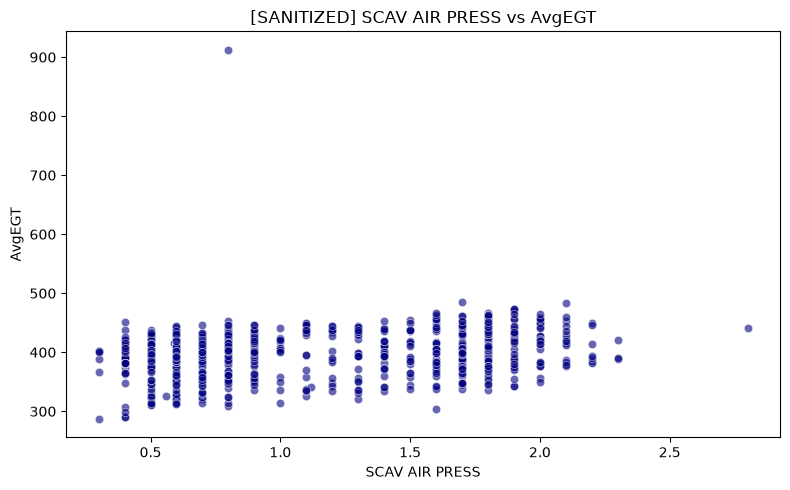

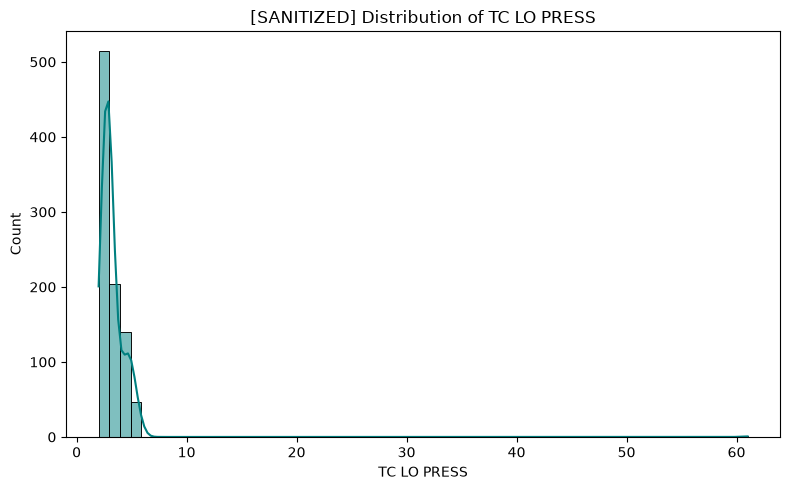

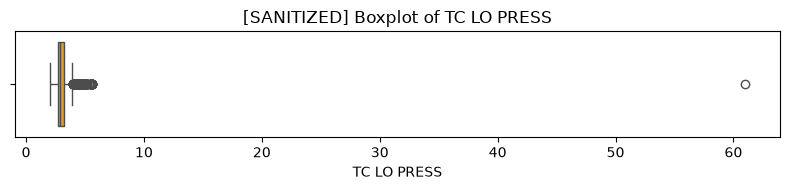

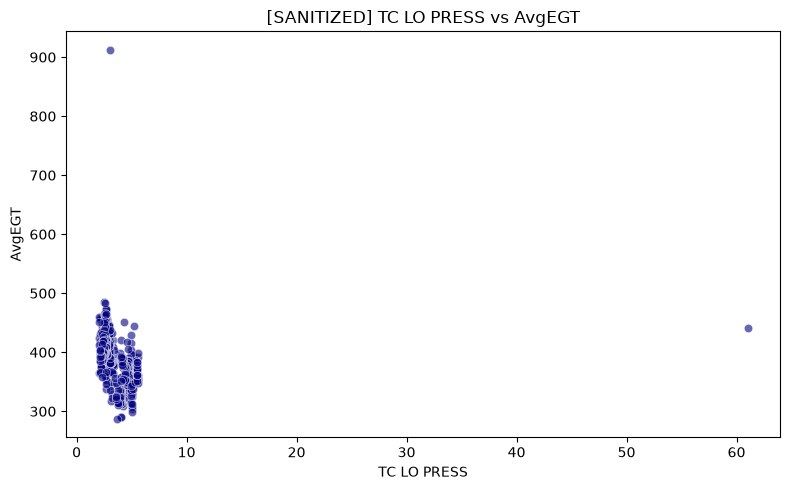

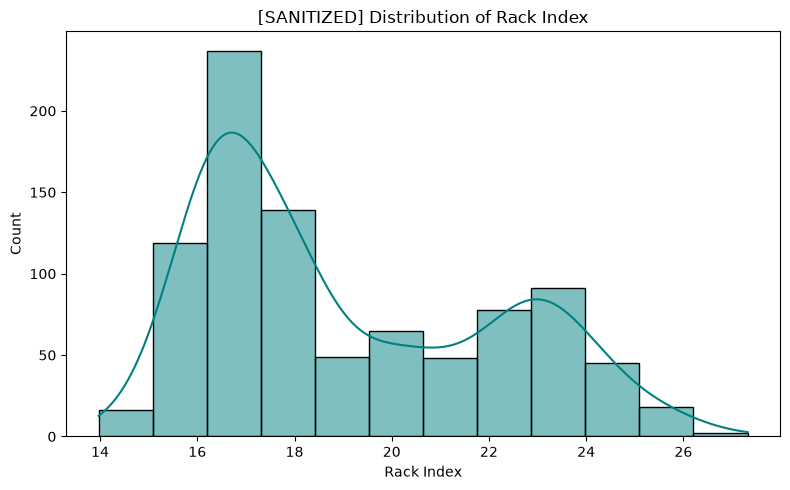

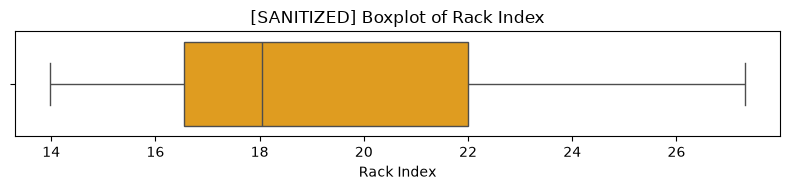

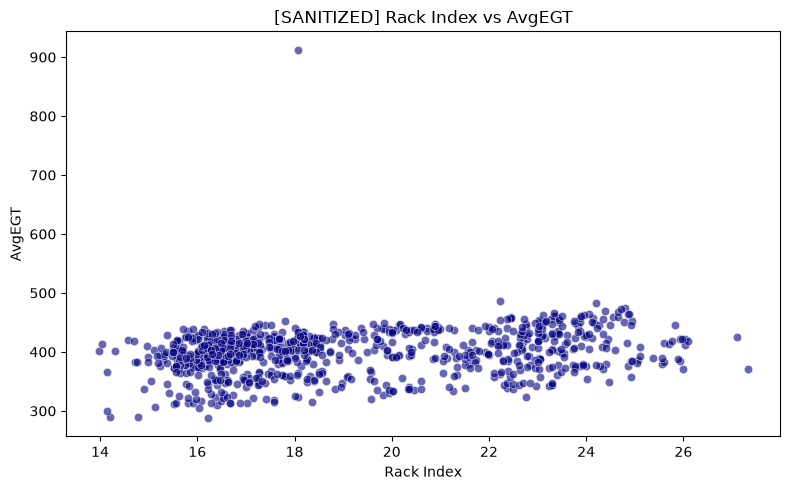

Generating SHAP interpretability plots (Inline)...


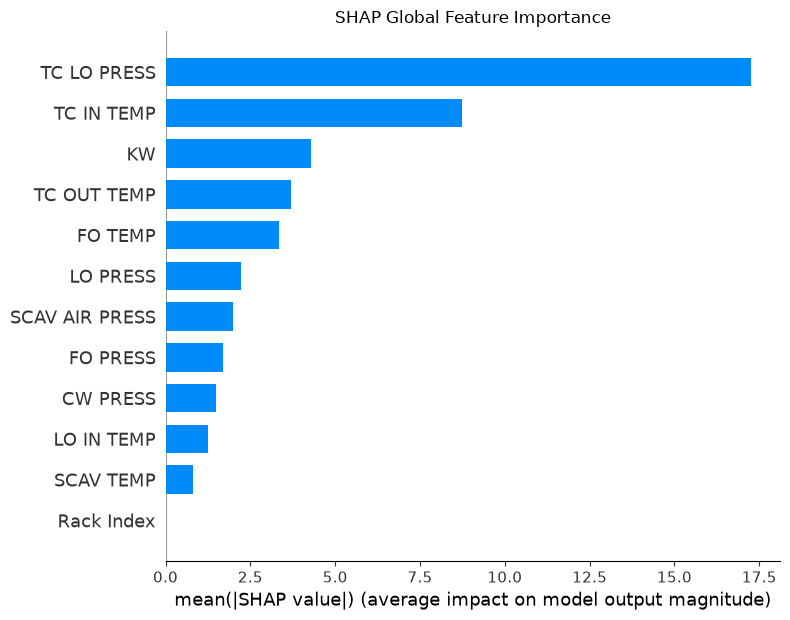

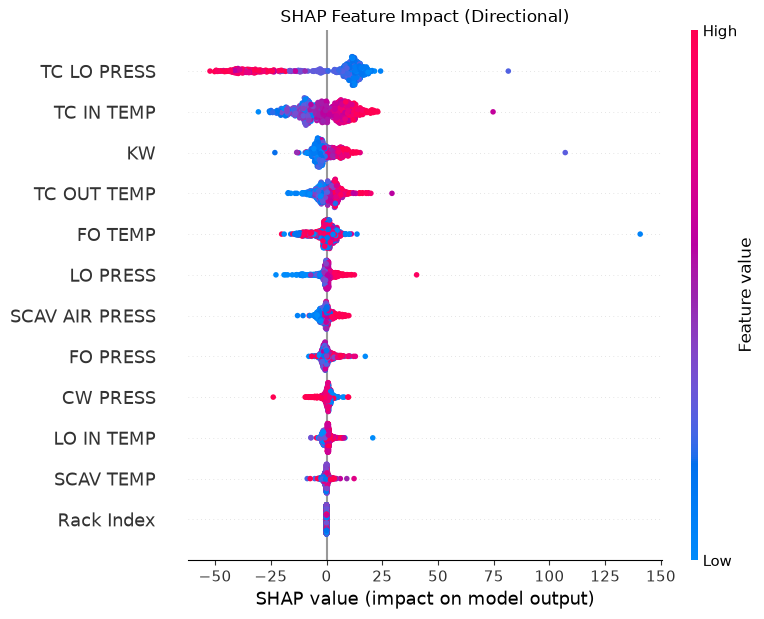

All 220+ exhaustive plots have been rendered inline successfully!


In [11]:
def generate_feature_loops_inline(df, prefix=""):
    features = [c for c in df.columns if c != TARGET_COL]
    for i, feature in enumerate(features):
        # 1. Feature Distribution
        plt.figure(figsize=(8, 5))
        sns.histplot(df[feature], kde=True, color='teal')
        plt.title(f'[{prefix.upper()}] Distribution of {feature}')
        plt.tight_layout()
        plt.show()
        
        # 2. Boxplot
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df[feature], color='orange')
        plt.title(f'[{prefix.upper()}] Boxplot of {feature}')
        plt.tight_layout()
        plt.show()
        
        # 3. Scatter vs Target
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x=feature, y=TARGET_COL, alpha=0.6, color='navy')
        plt.title(f'[{prefix.upper()}] {feature} vs {TARGET_COL}')
        plt.tight_layout()
        plt.show()

print("Generating exhaustive Full Dataset EDA loops (Inline)...")
generate_feature_loops_inline(df_raw, prefix="full")

print("Generating exhaustive Sanitized Dataset EDA loops (Inline)...")
generate_feature_loops_inline(df_clean, prefix="sanitized")

print("Generating SHAP interpretability plots (Inline)...")
try:
    explainer = shap.TreeExplainer(best_model_instance)
    shap_values = explainer.shap_values(X_train_scaled)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_train_scaled, plot_type="bar", show=False)
    plt.title('SHAP Global Feature Importance')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_train_scaled, show=False)
    plt.title('SHAP Feature Impact (Directional)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP generation failed: {e}")

print("All 220+ exhaustive plots have been rendered inline successfully!")